In [1]:
import torch
from torch import nn, optim
from torchvision import datasets, transforms
from torch.optim.lr_scheduler import CosineAnnealingLR
import numpy as np
import matplotlib.pyplot as plt

from ViTGSOM import AutoEncoder, ViTLossReconstruction, SomLoss
from help_functions import get_grid_coords, decay_exponential, calculate_QE_TE_Purity, plot_umap_som_weights, get_node_hits, plot_som_weights, plot_som_mnist, plot_som_pie_grid

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(), 
])

dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)

In [5]:
dataset.class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [3]:
config = {
    'img_size': 28,
    'patch_size': 4,
    'num_of_channels': 1,
    'embed_dim': 16,
    'enc_depth': 4,
    'dec_depth': 2,
    'num_heads': 2,
    'mlp_dim': 64,
    'epochs_pretrain': 20,
    'epochs_som': 500,
    'fine_tuning_epochs': 100,
    'lr': 0.0005,
    'grow_after_epochs': 10,
    'som_rows': 8,
    'som_cols': 8,
    'stop_growth_purity': 0.80
}

In [4]:
autoencoder = AutoEncoder(img_size=config['img_size'], 
                          patch_size=config['patch_size'], 
                          num_of_channels=config['num_of_channels'], 
                          embed_dim=config['embed_dim'], 
                          enc_depth=config['enc_depth'],                                      
                          dec_depth=config['dec_depth'], 
                          num_heads=config['num_heads'], 
                          mlp_dim=config['mlp_dim'],
                          som_rows=config['som_rows'],
                          som_cols=config['som_cols'])    

In [5]:
criterionViT = ViTLossReconstruction()
criterionSOM = SomLoss()

loader = torch.utils.data.DataLoader(dataset=dataset, batch_size=32, shuffle=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

autoencoder.to(device)
autoencoder.train()

AutoEncoder(
  (encoder): ViTEncoder(
    (patch_embed): PatchEmbedding(
      (proj): Conv2d(1, 16, kernel_size=(4, 4), stride=(4, 4))
    )
    (blocks): ModuleList(
      (0-3): 4 x Block(
        (attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=16, out_features=16, bias=True)
        )
        (ln1): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (dense_1): Linear(in_features=16, out_features=64, bias=True)
          (activation): GELU(approximate='none')
          (dense_2): Linear(in_features=64, out_features=16, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (ln2): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
      )
    )
    (ln1): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
  )
  (decoder): ViTDecoder(
    (blocks): ModuleList(
      (0-1): 2 x Block(
        (attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLine

## Phase 1: Pretrain ViT

In [21]:
autoencoder.som_weights.requires_grad = False
for param in autoencoder.encoder.parameters():
    param.requires_grad = True
for param in autoencoder.decoder.parameters():
    param.requires_grad = True
    
paramsViT = list(autoencoder.encoder.parameters()) + list(autoencoder.decoder.parameters())
optimizerViT = optim.AdamW(paramsViT, lr=config['lr'])
scheduler = CosineAnnealingLR(optimizerViT, T_max=config['epochs_pretrain'])

history = {'MSE': []}

for epoch in range(config['epochs_pretrain']):
    running_mse = 0.0
    
    for images, _ in loader:
        images = images.to(device)
        
        reconstructed, latent, _ = autoencoder(images)
        som_weights = autoencoder.get_som_weights()
        
        l_nn = criterionViT(images, reconstructed)
        
        optimizerViT.zero_grad()
        l_nn.backward()
        optimizerViT.step()
        running_mse += l_nn.item()
        
    scheduler.step()
    history['MSE'].append(running_mse/len(loader))
        
    print(f"Epoch {epoch+1}/{config['epochs_pretrain']}: MSE Loss {running_mse/len(loader):.8f}")

Epoch 1/20: MSE Loss 0.01827907
Epoch 2/20: MSE Loss 0.00329612
Epoch 3/20: MSE Loss 0.00177602
Epoch 4/20: MSE Loss 0.00136038
Epoch 5/20: MSE Loss 0.00118345
Epoch 6/20: MSE Loss 0.00104739
Epoch 7/20: MSE Loss 0.00086463
Epoch 8/20: MSE Loss 0.00066367
Epoch 9/20: MSE Loss 0.00061850
Epoch 10/20: MSE Loss 0.00059452
Epoch 11/20: MSE Loss 0.00057855
Epoch 12/20: MSE Loss 0.00056698
Epoch 13/20: MSE Loss 0.00055806
Epoch 14/20: MSE Loss 0.00055143
Epoch 15/20: MSE Loss 0.00054658
Epoch 16/20: MSE Loss 0.00054298
Epoch 17/20: MSE Loss 0.00054022
Epoch 18/20: MSE Loss 0.00053853
Epoch 19/20: MSE Loss 0.00053731
Epoch 20/20: MSE Loss 0.00053683


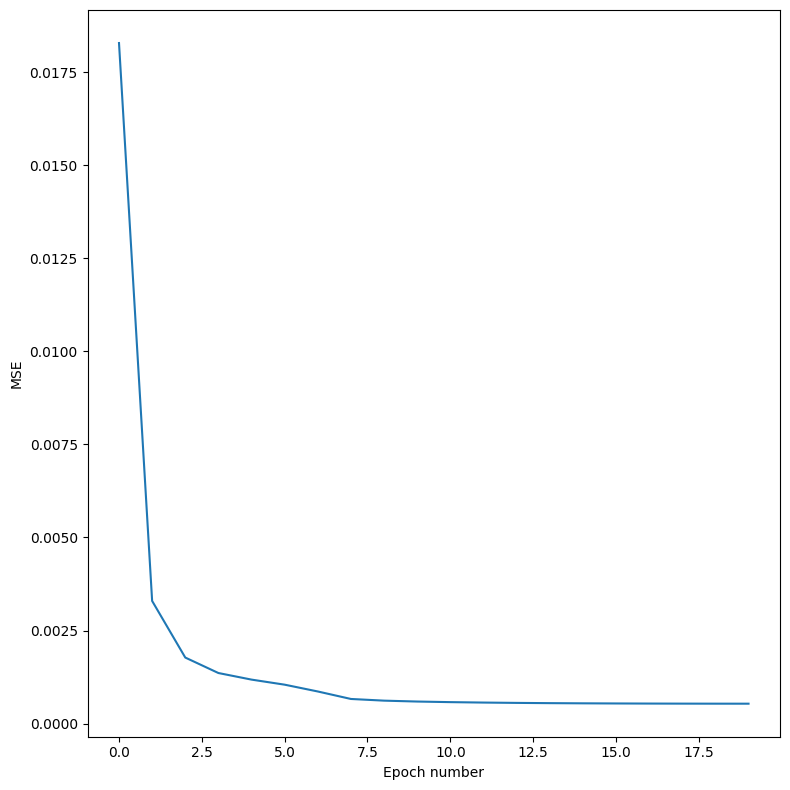

In [22]:
plt.figure(figsize=(8, 8))
plt.plot(np.arange(config['epochs_pretrain']), history['MSE'])
plt.ylabel('MSE')
plt.xlabel('Epoch number')
plt.tight_layout()
plt.show()

## Phase 2: GSOM training

In [23]:
torch.save(autoencoder, "D:/Tom/ViT-GHSOM/model_fmnist_early.pth")

In [7]:
autoencoder = torch.load("D:/Tom/ViT-GHSOM/model_fmnist_early.pth",weights_only=False)

In [8]:
autoencoder.som_weights.requires_grad = True
for param in autoencoder.encoder.parameters():
    param.requires_grad = False
for param in autoencoder.decoder.parameters():
    param.requires_grad = False

paramsSOM = autoencoder.som_weights
optimizerSOM = optim.AdamW([paramsSOM], lr=config['lr'])
scheduler = CosineAnnealingLR(optimizerSOM, T_max=config['epochs_som'])

sigma_start = autoencoder.get_sigma()
sigma_end = 0.3
beta = (sigma_end / sigma_start) ** (1 / config['grow_after_epochs'])
epochs_since_reset = 0

grid_coords = get_grid_coords(config['som_rows'], config['som_cols'], device)
current_sigma = sigma_start

history = {'som': [], 'purity': [], 'QE': [], 'TE': []}


snapshot_som_weights = {}
snapshot_som_weights[0] = (
    autoencoder.get_som_weights().detach().cpu().numpy(),
    get_node_hits(autoencoder, loader, device)
)

unique_labels = set()

print("Start GSOM training")
for epoch in range(config['epochs_som']):
    
    running_som = 0.0
    
    sigma_t = decay_exponential(sigma_start, beta, epochs_since_reset)

    for images, labels in loader:
        images = images.to(device)
        unique_labels.update(labels.tolist())
        
        reconstructed, latent, _ = autoencoder(images)
        som_weights = autoencoder.get_som_weights()
        
        l_som = criterionSOM(latent, som_weights, grid_coords, sigma_t)
        
        optimizerSOM.zero_grad()
        l_som.backward()
        optimizerSOM.step()
        
        running_som += l_som.item()
    
    # updating learning rule through CosineAnnealingLR
    scheduler.step()

    metrics = calculate_QE_TE_Purity(autoencoder, loader, device)
    
    avg_som = running_som / len(loader)

    history['som'].append(avg_som)
    history['purity'].append(metrics["Purity"])
    history['QE'].append(metrics["QE"])
    history['TE'].append(metrics["TE"])
    
    print(f"Epoch {epoch+1}/{config['epochs_som']} | Sigma: {sigma_t:.3f} | SOM: {avg_som:.8f}) | QE: {metrics["QE"]:.4f} | TE: {metrics["TE"]:.4f} | Purity: {metrics["Purity"]:.5f}")
        
    if epoch > 0 and (epoch + 1) % config['grow_after_epochs'] == 0:     
        weights_np = autoencoder.get_som_weights().detach().cpu().numpy()
        labels_np = get_node_hits(autoencoder, loader, device)
        snapshot_som_weights[epoch] = (weights_np, labels_np)

        if metrics["Purity"] > config['stop_growth_purity']:
            print(f"Purity is high enough: {metrics["Purity"]}, entering Phase 3 - Fine-tuning")
            break
        
        epochs_since_reset += 1
        autoencoder.start_growth(loader, device)
        paramsSOM = autoencoder.get_som_weights()
        optimizerSOM = optim.AdamW([paramsSOM], lr=config['lr'])

        for param_group in optimizerSOM.param_groups: param_group['initial_lr'] = config['lr']

        scheduler = CosineAnnealingLR(optimizerSOM, T_max=config['epochs_som'], last_epoch=epoch)
        grid_coords = get_grid_coords(autoencoder.current_row_num, autoencoder.current_col_num, device)

        sigma_start = autoencoder.get_sigma()
        sigma_start = max(sigma_start, 2.0)
        beta = (sigma_end / sigma_start) ** (1 / max(1, config['grow_after_epochs']))
        epochs_since_reset = 0

    else:
        epochs_since_reset += 1   

Start GSOM training
Epoch 1/500 | Sigma: 4.000 | SOM: 27.44218037) | QE: 0.2320 | TE: 0.2002 | Purity: 0.10003
Epoch 2/500 | Sigma: 3.087 | SOM: 5.65825542) | QE: 0.0560 | TE: 0.0000 | Purity: 0.16443
Epoch 3/500 | Sigma: 2.383 | SOM: 1.63624631) | QE: 0.0402 | TE: 0.1020 | Purity: 0.24603
Epoch 4/500 | Sigma: 1.839 | SOM: 0.64784486) | QE: 0.0266 | TE: 0.0320 | Purity: 0.51135
Epoch 5/500 | Sigma: 1.419 | SOM: 0.30562476) | QE: 0.0221 | TE: 0.0050 | Purity: 0.58022
Epoch 6/500 | Sigma: 1.095 | SOM: 0.15374833) | QE: 0.0198 | TE: 0.0104 | Purity: 0.62895
Epoch 7/500 | Sigma: 0.845 | SOM: 0.08659229) | QE: 0.0184 | TE: 0.0228 | Purity: 0.66293
Epoch 8/500 | Sigma: 0.653 | SOM: 0.05061773) | QE: 0.0174 | TE: 0.0364 | Purity: 0.67678
Epoch 9/500 | Sigma: 0.504 | SOM: 0.02984124) | QE: 0.0165 | TE: 0.0868 | Purity: 0.69775
Epoch 10/500 | Sigma: 0.389 | SOM: 0.01944668) | QE: 0.0159 | TE: 0.1633 | Purity: 0.71097
Current grid size: (8, 9)
Epoch 11/500 | Sigma: 4.000 | SOM: 1.32811494) | QE:

KeyboardInterrupt: 

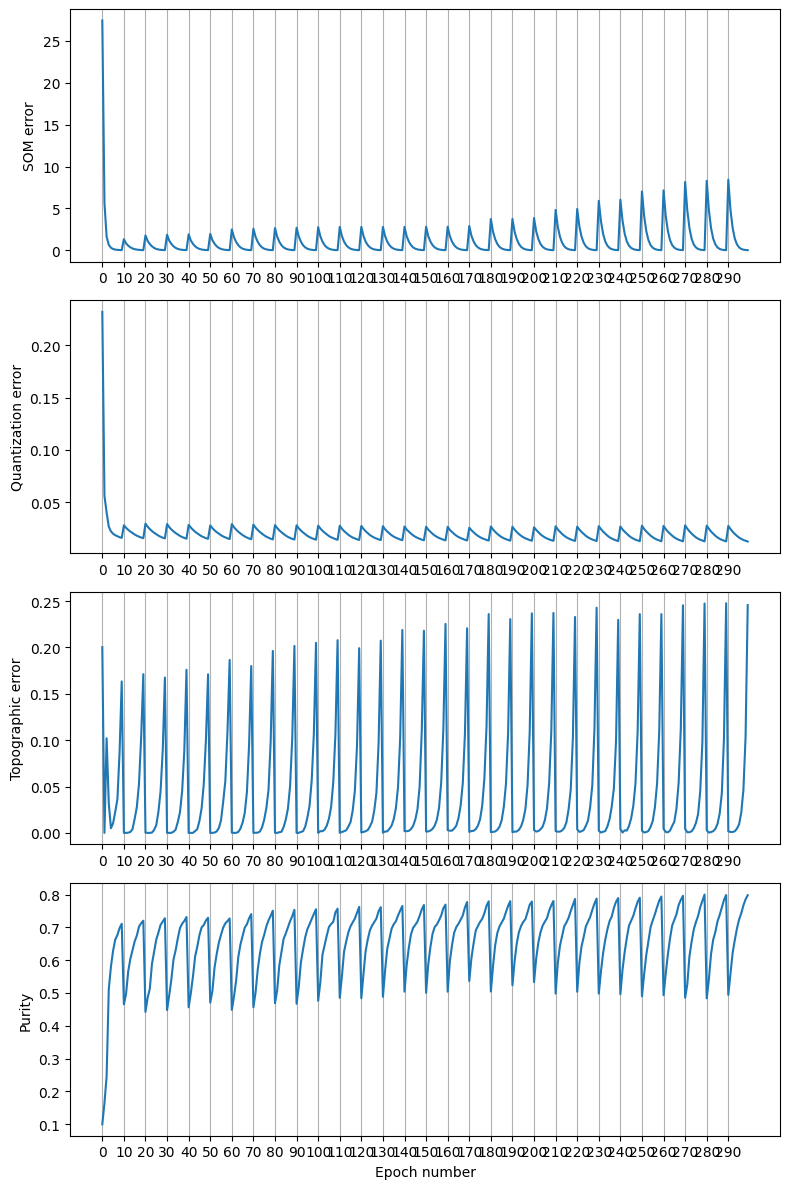

In [11]:
epochs_completed = len(history['QE'])
x = np.arange(epochs_completed)
xticks = np.arange(0, epochs_completed, 10)

plt.figure(figsize=(8, 12))

plt.subplot(4,1,1)
plt.plot(x, history['som'])
plt.xticks(xticks)
plt.grid(axis='x')
plt.ylabel('SOM error')

plt.subplot(4,1,2)
plt.plot(x, history['QE'])
plt.xticks(xticks)
plt.grid(axis='x')
plt.ylabel('Quantization error')

plt.subplot(4,1,3)
plt.plot(x, history['TE'])
plt.xticks(xticks)
plt.grid(axis='x')
plt.ylabel('Topographic error')

plt.subplot(4,1,4)
plt.plot(x, history['purity'])
plt.xticks(xticks)
plt.grid(axis='x')
plt.ylabel('Purity')

plt.xlabel('Epoch number')
plt.tight_layout()
plt.show()

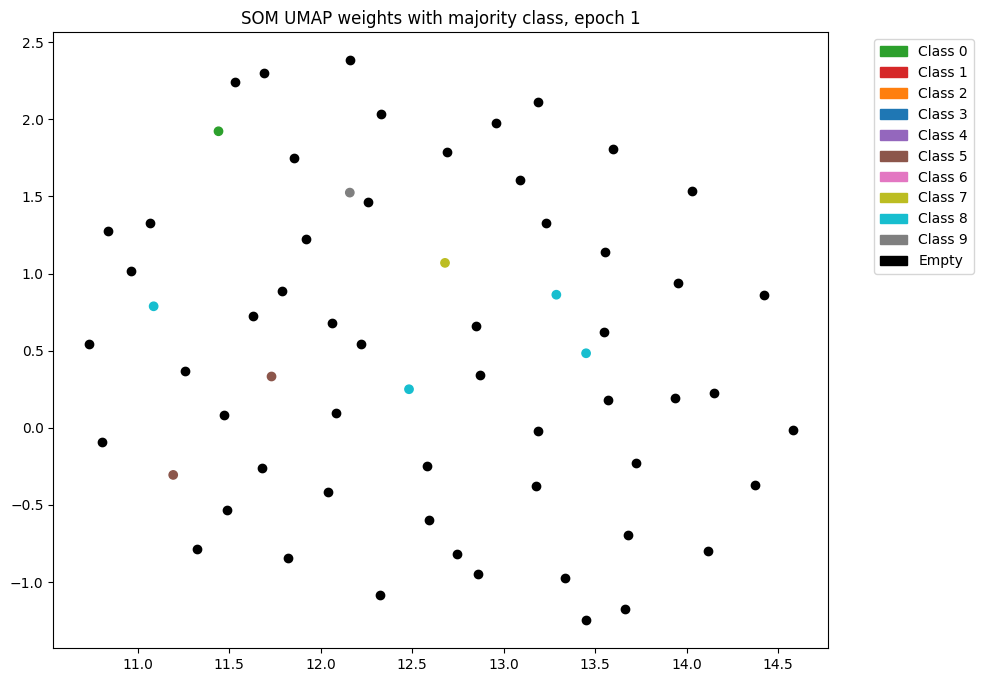

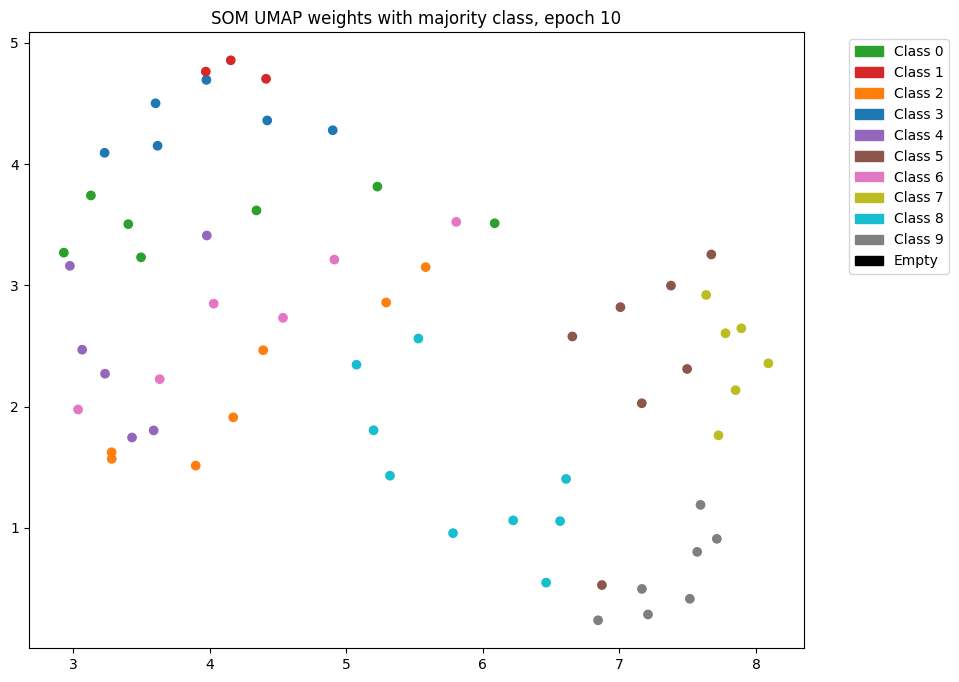

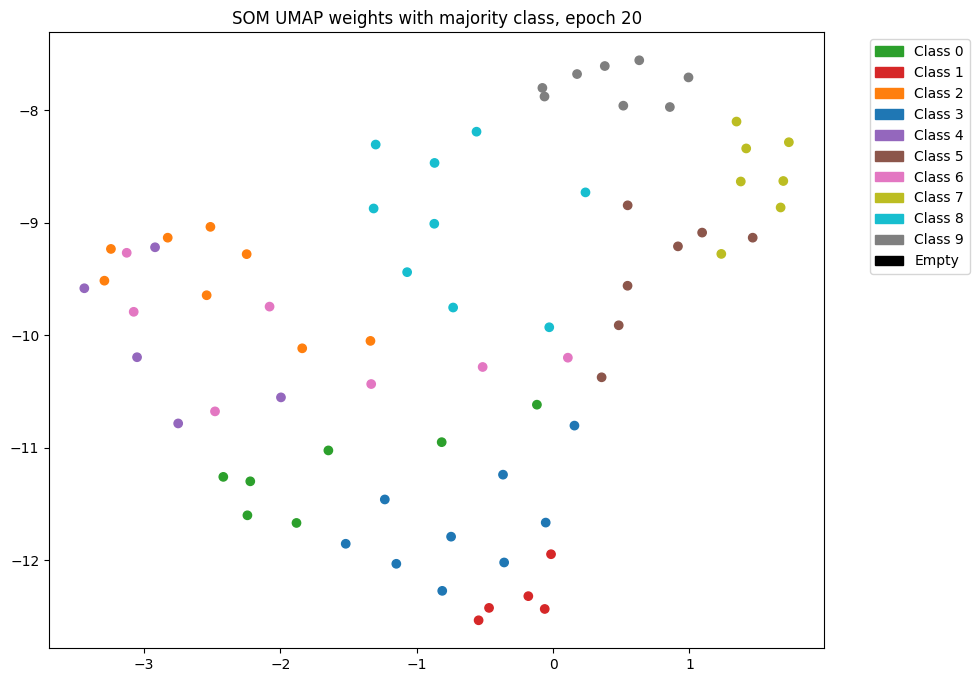

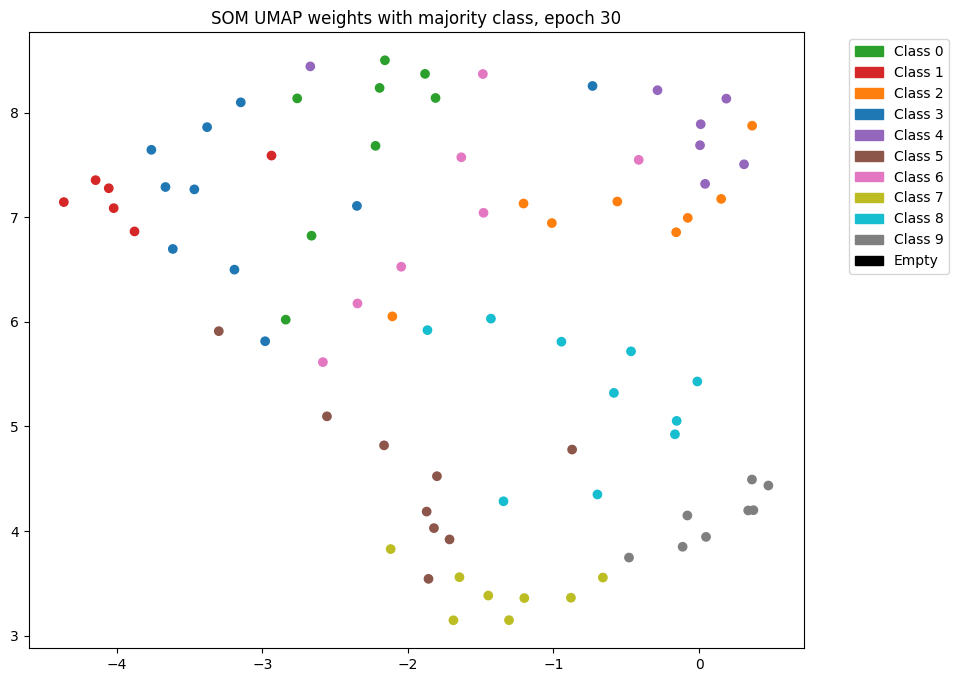

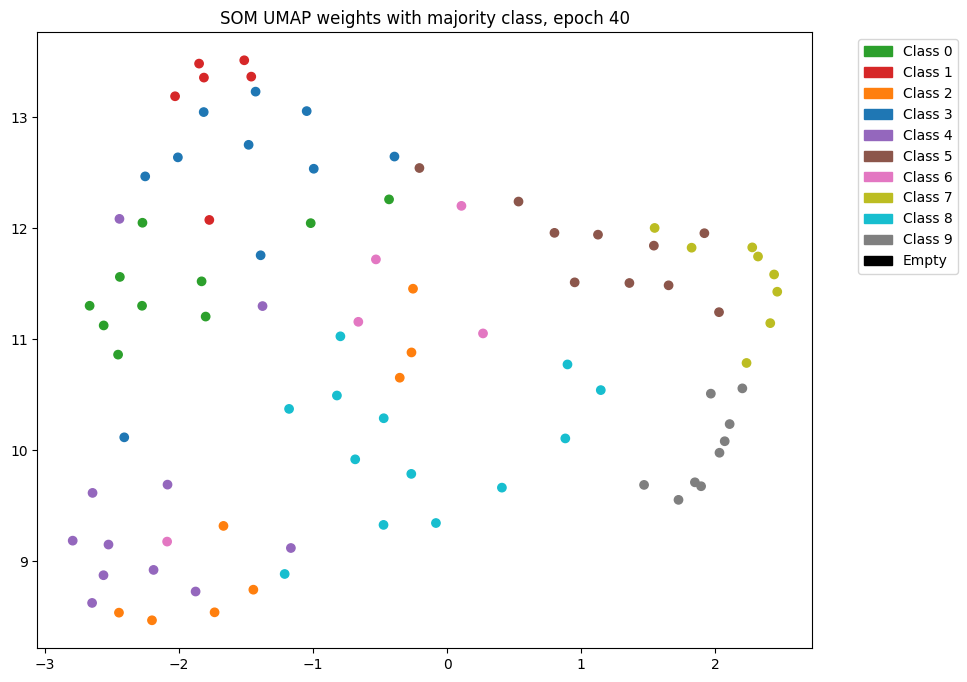

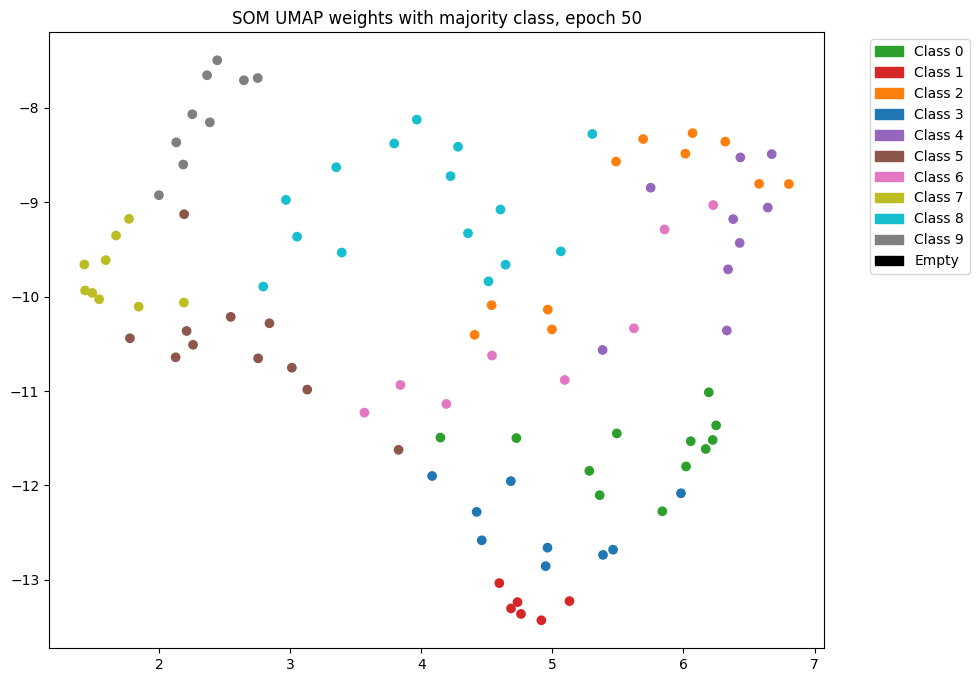

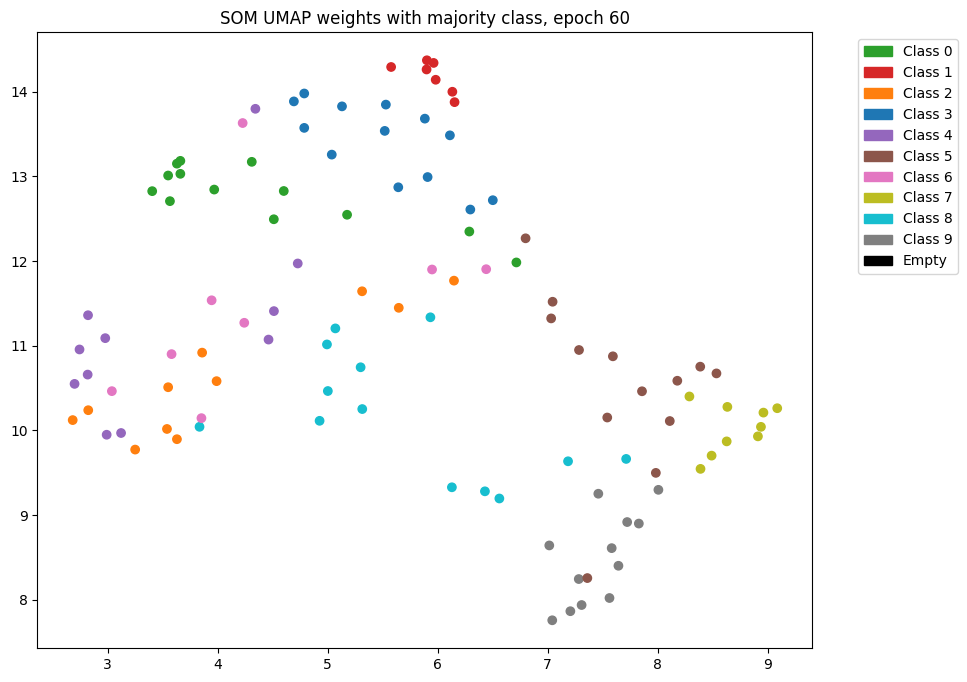

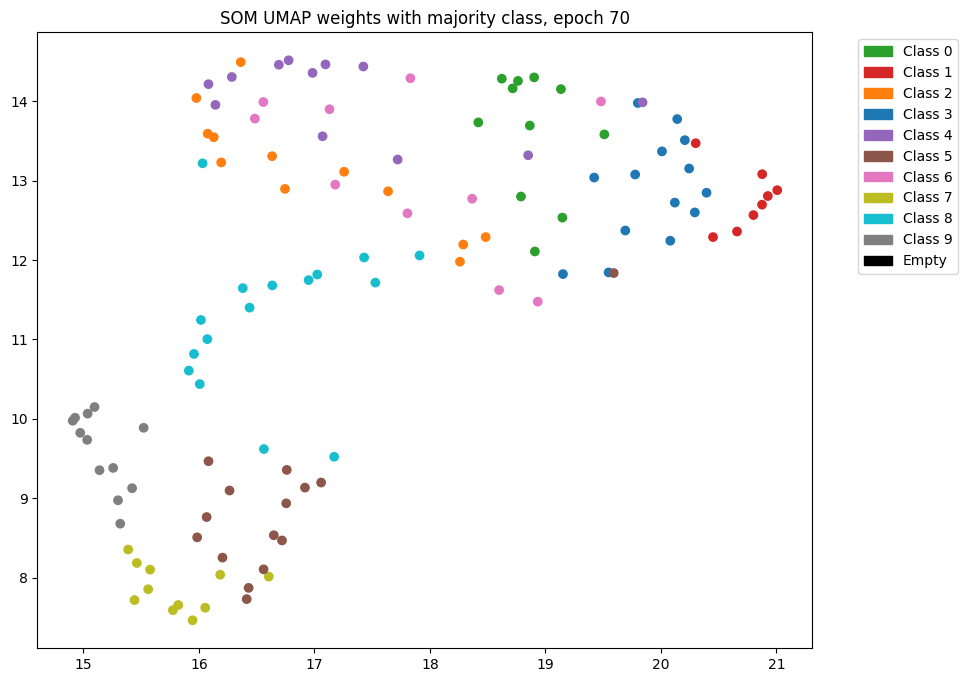

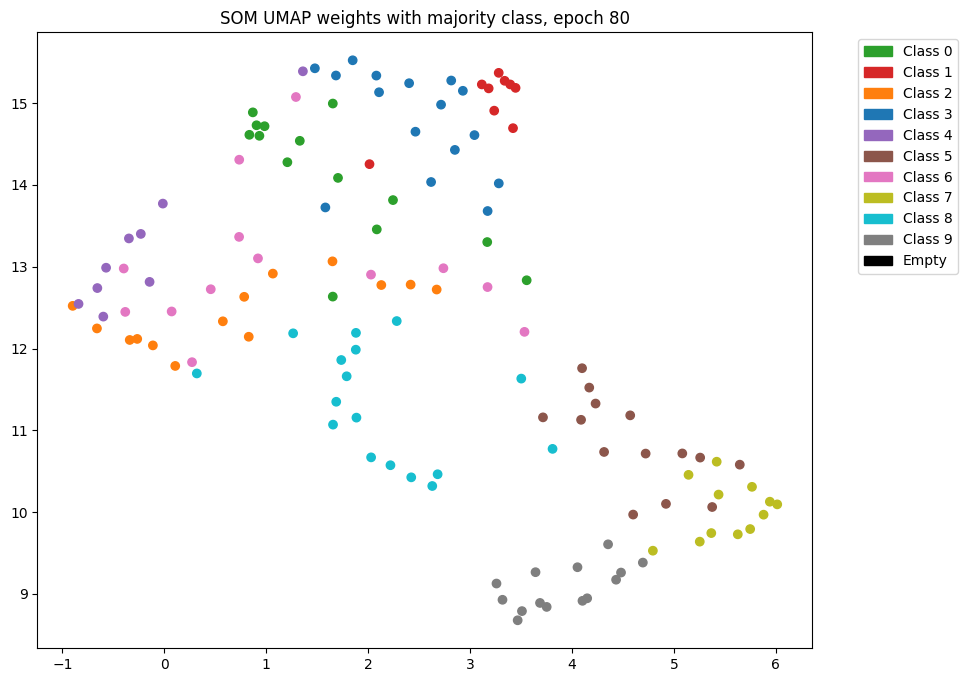

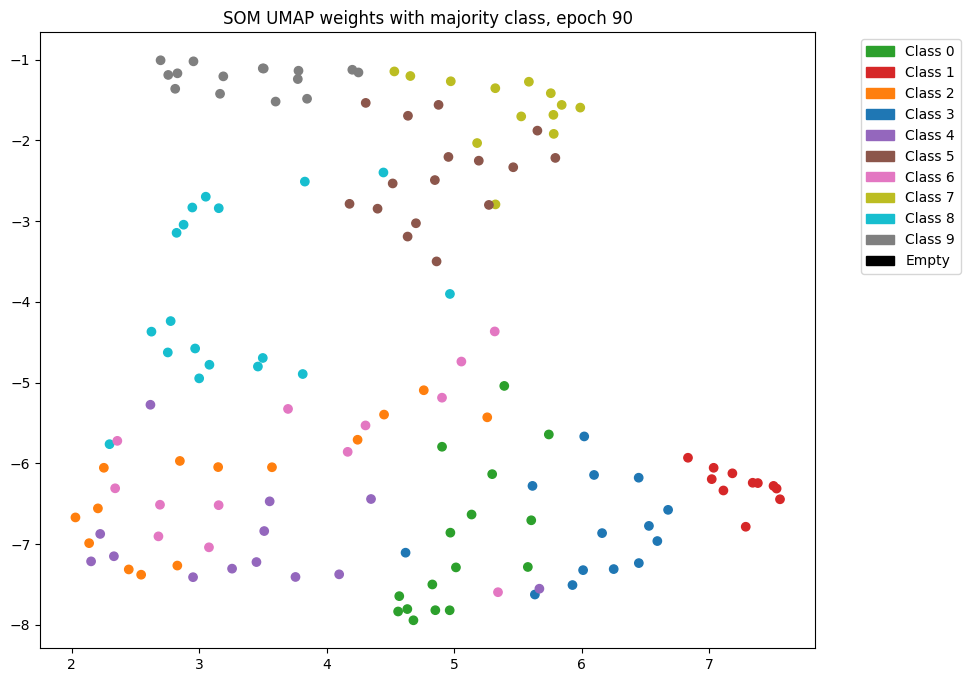

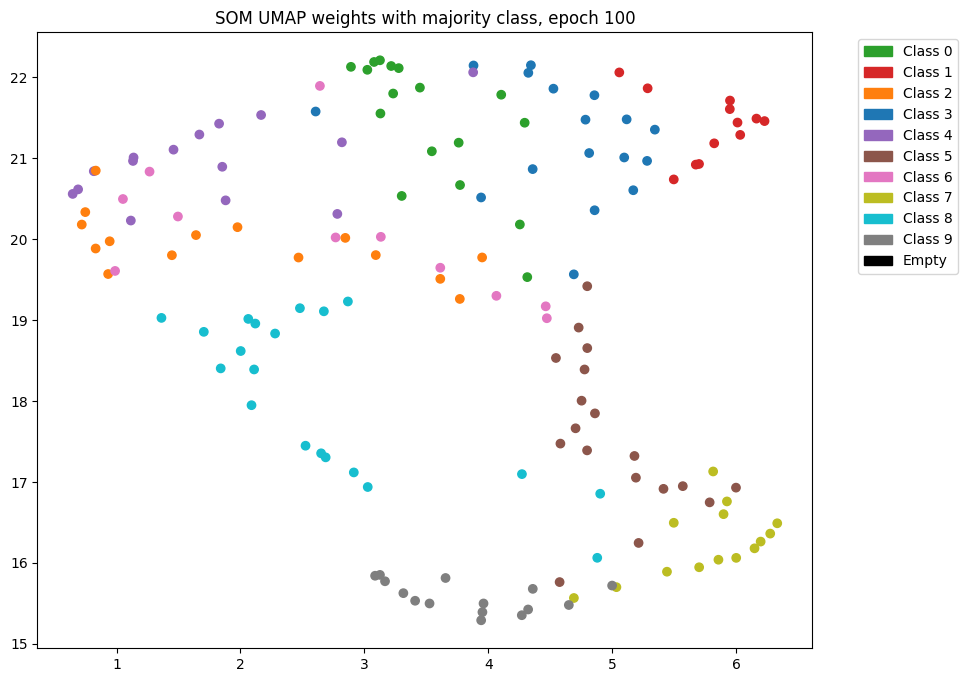

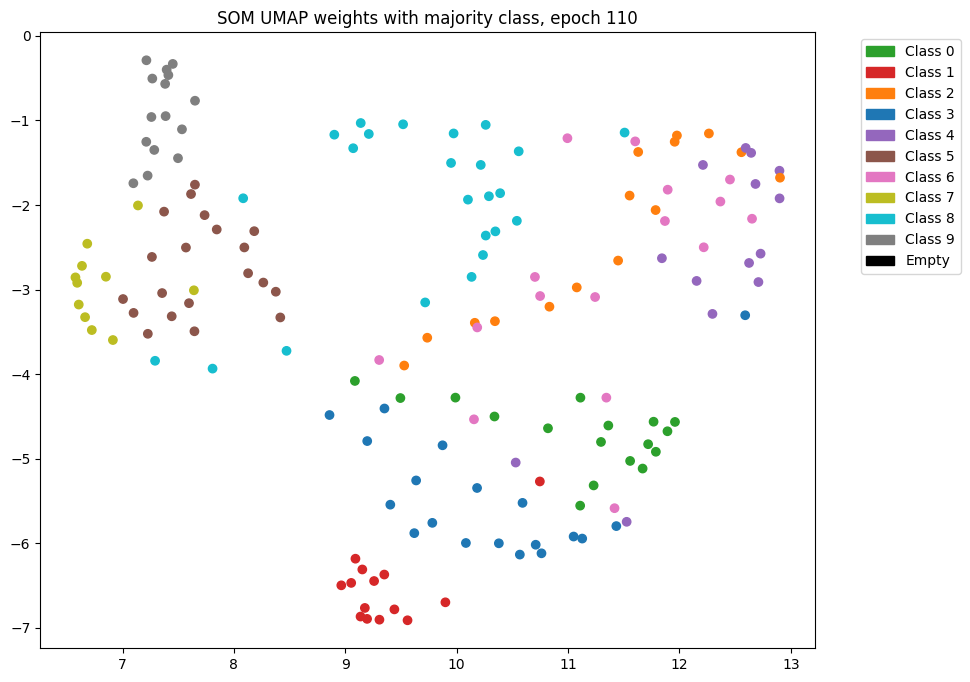

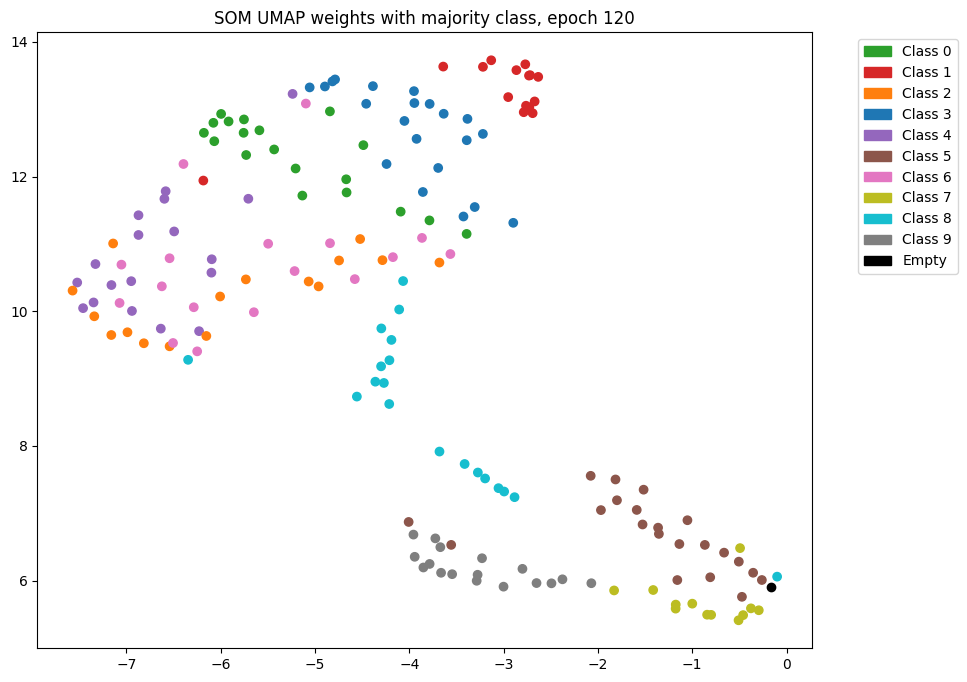

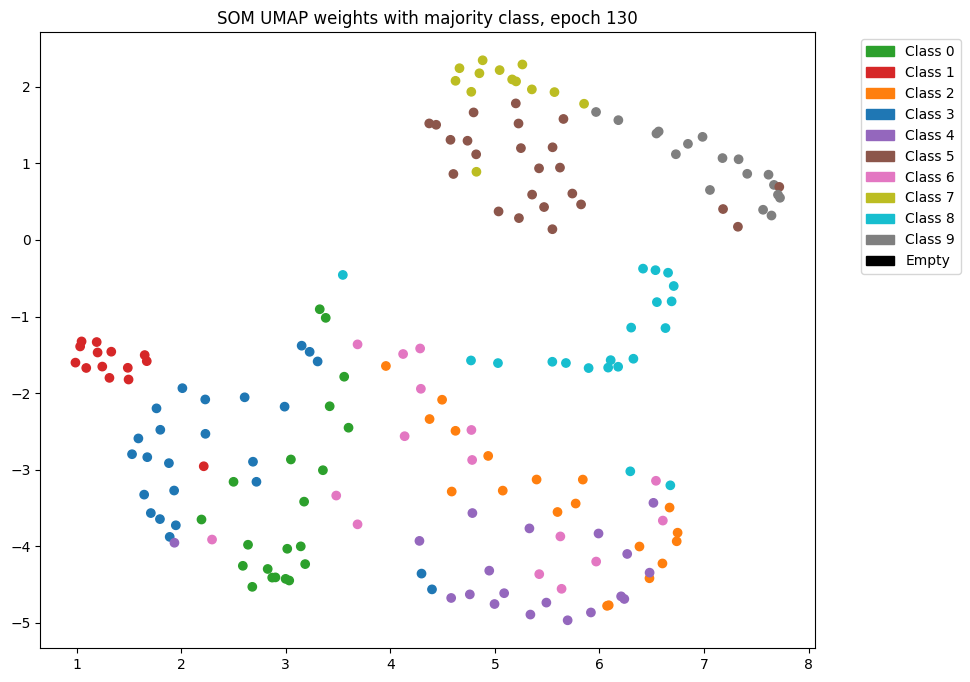

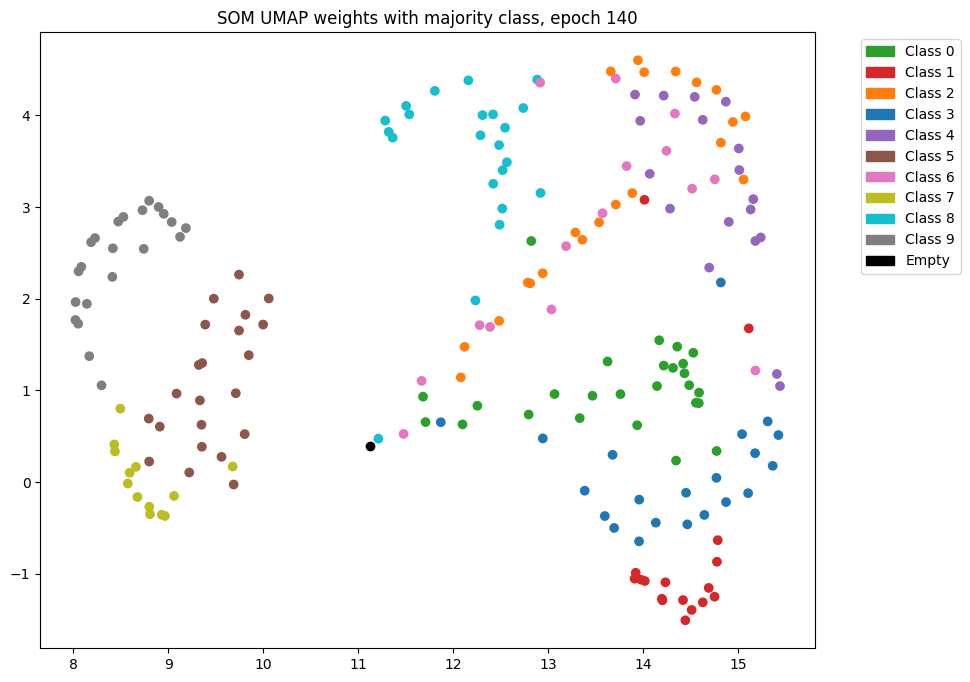

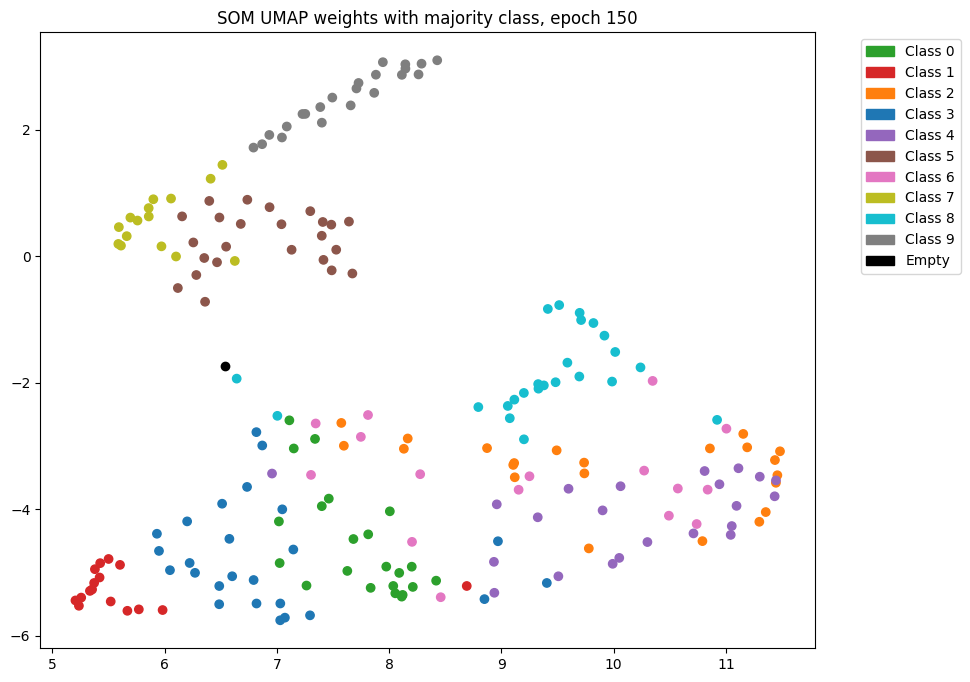

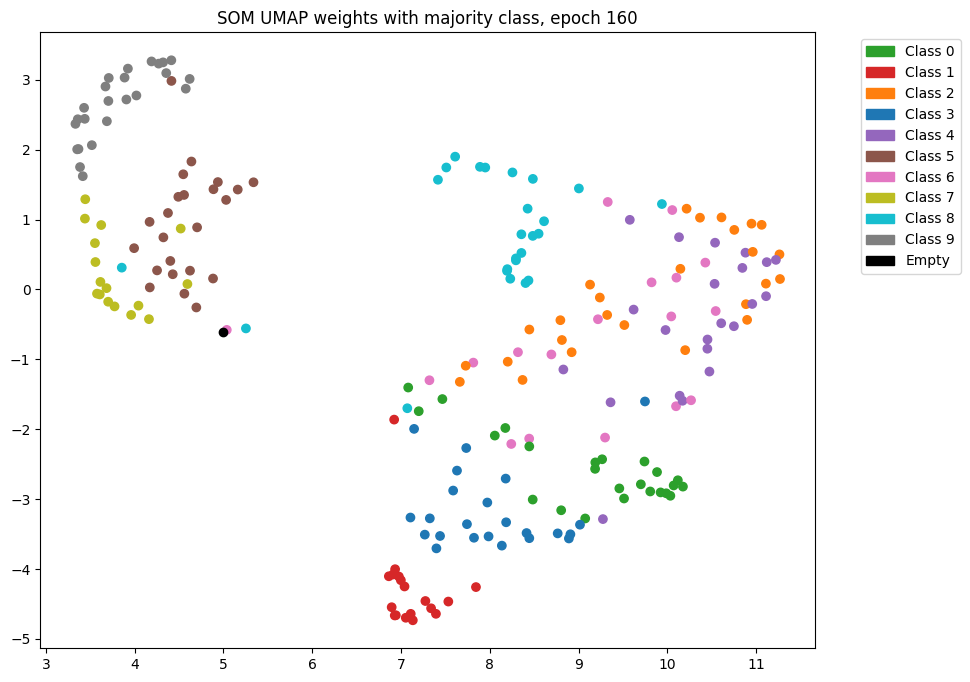

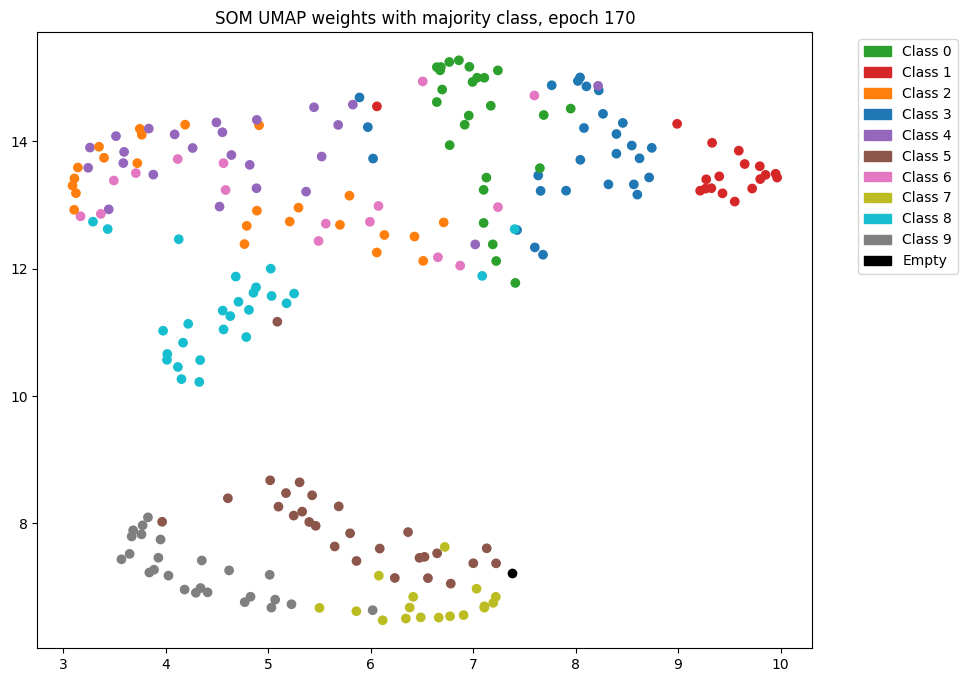

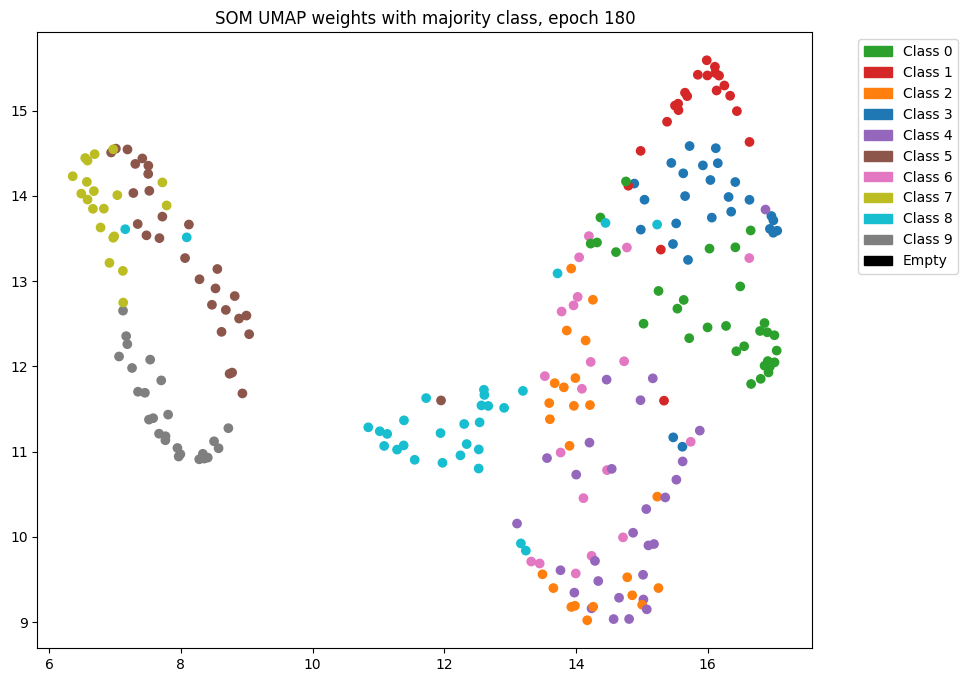

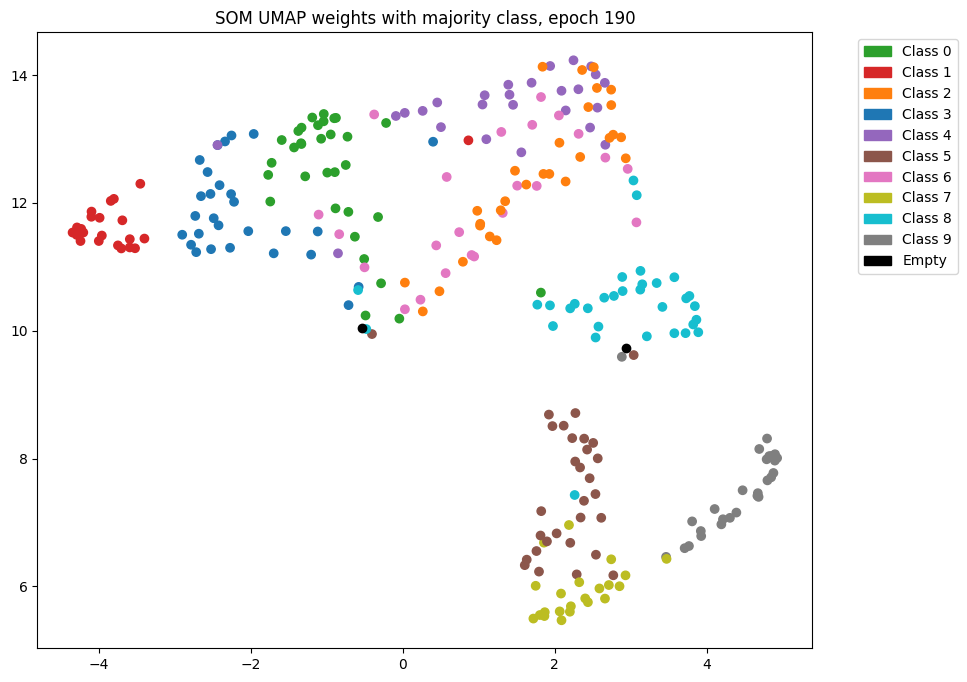

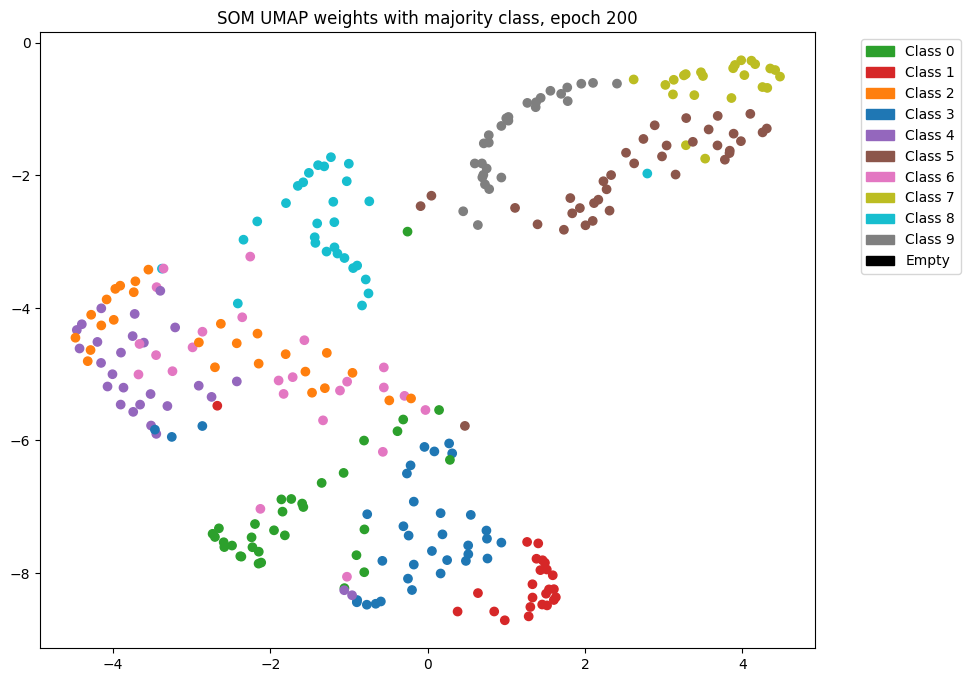

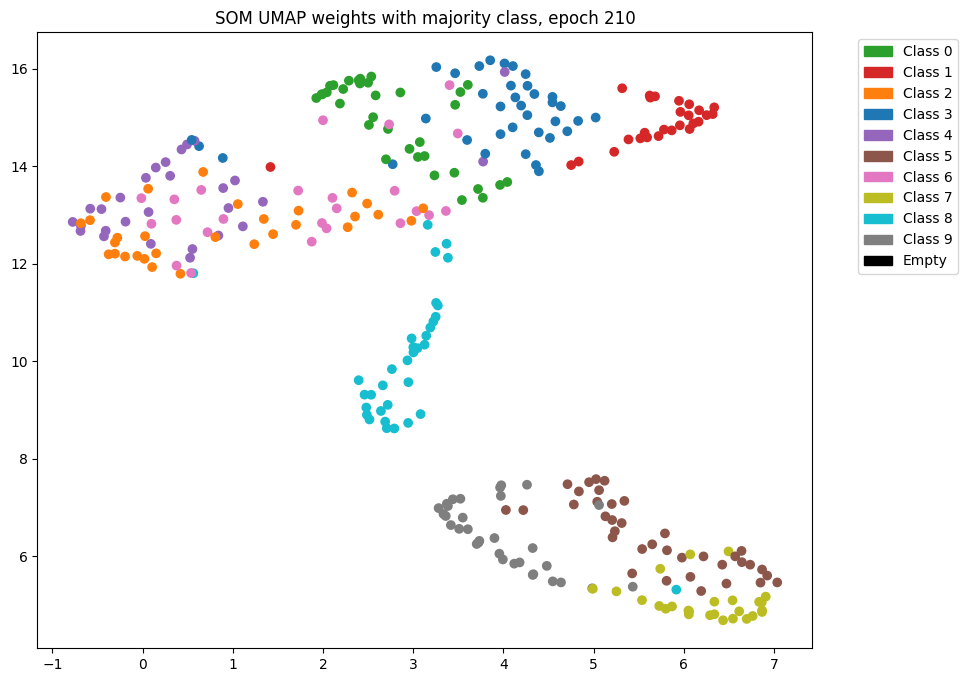

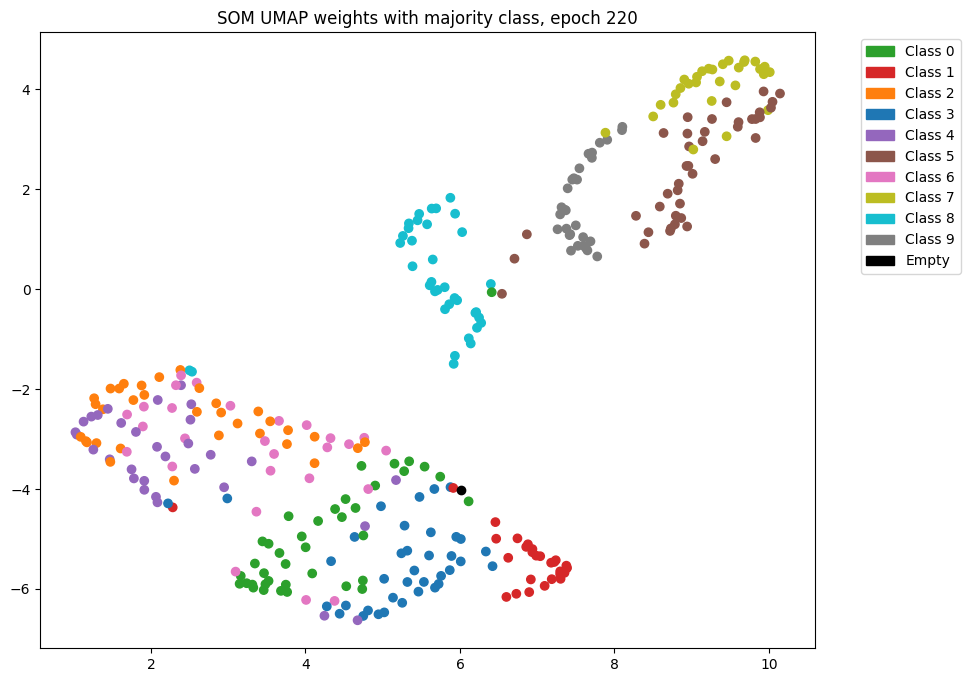

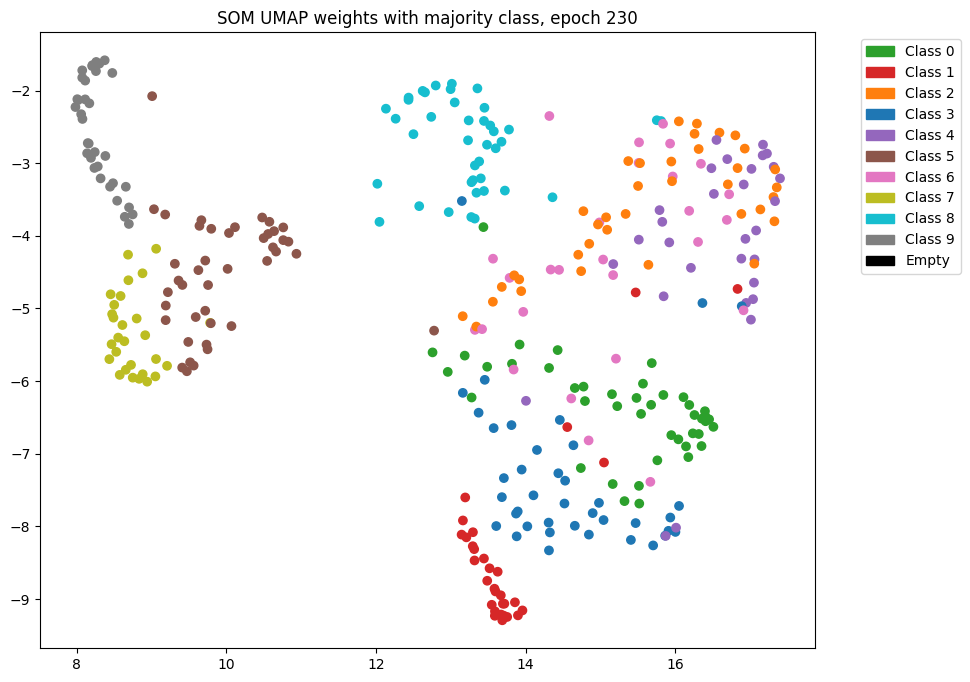

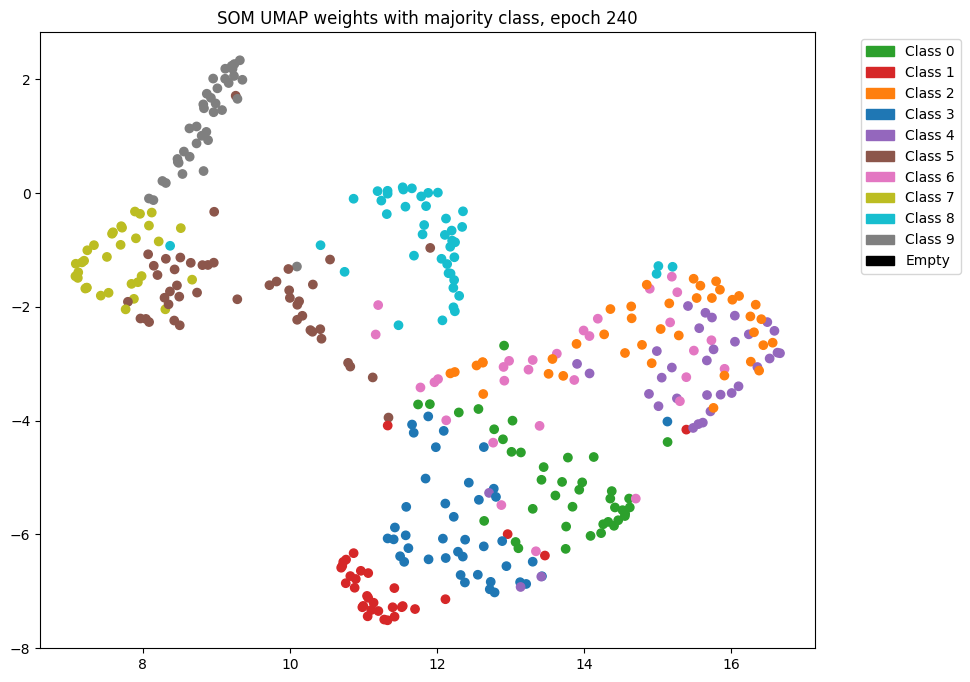

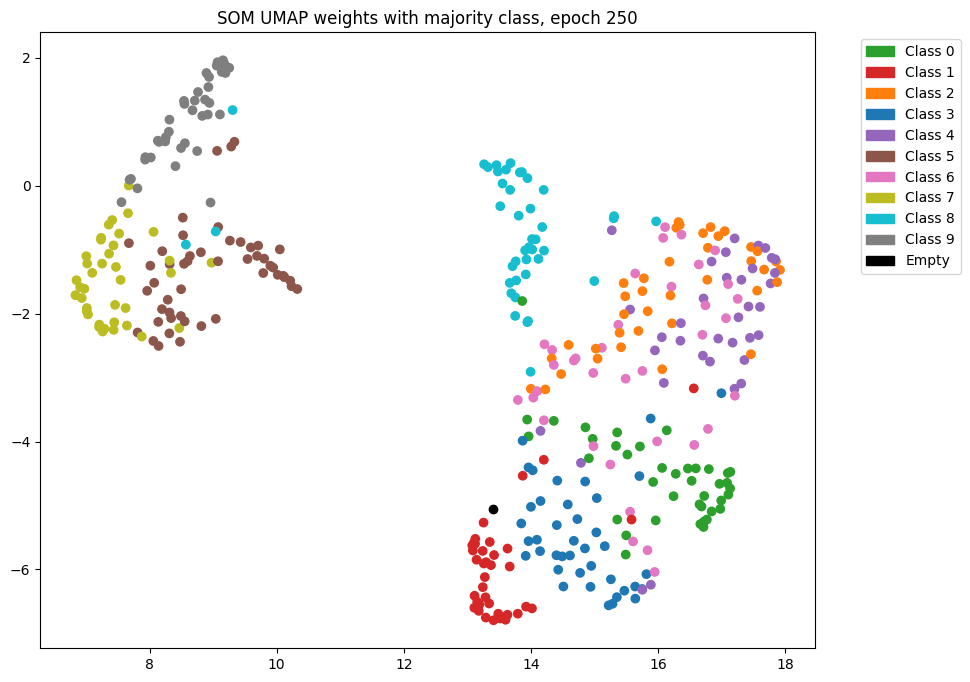

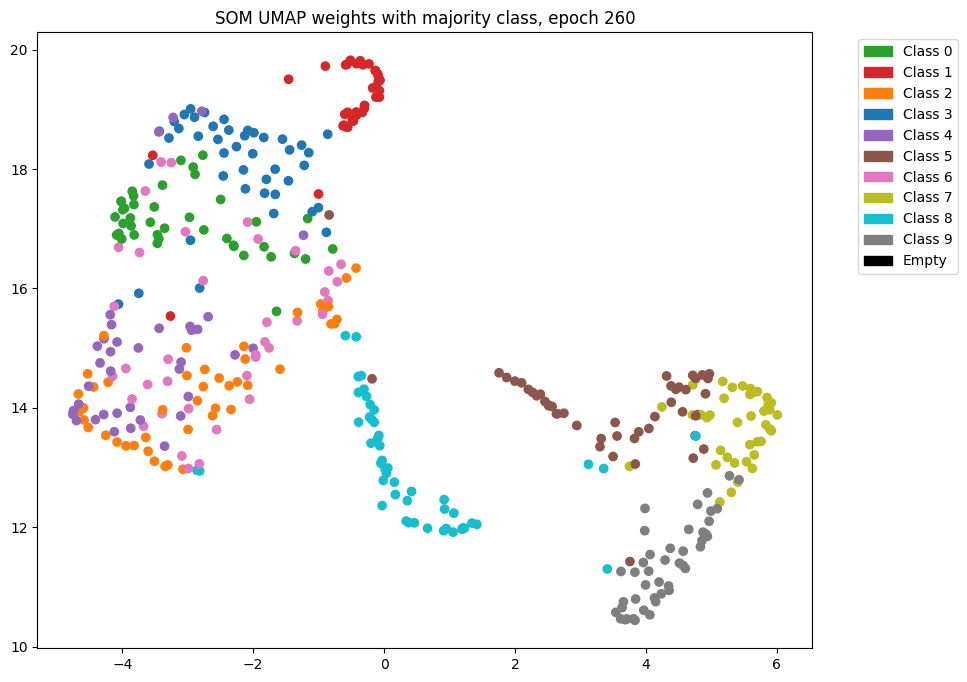

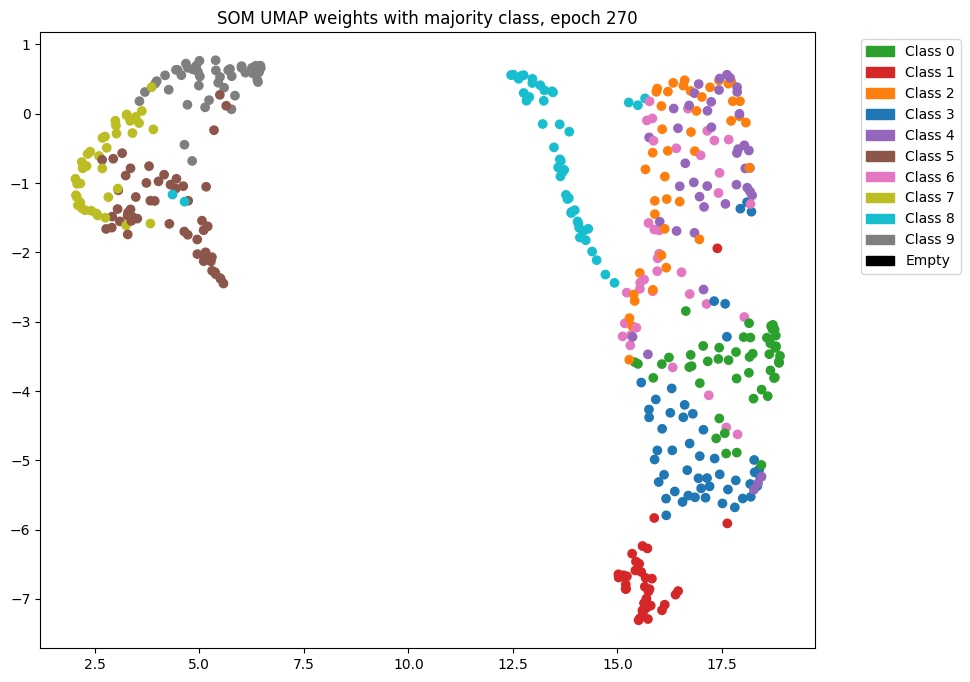

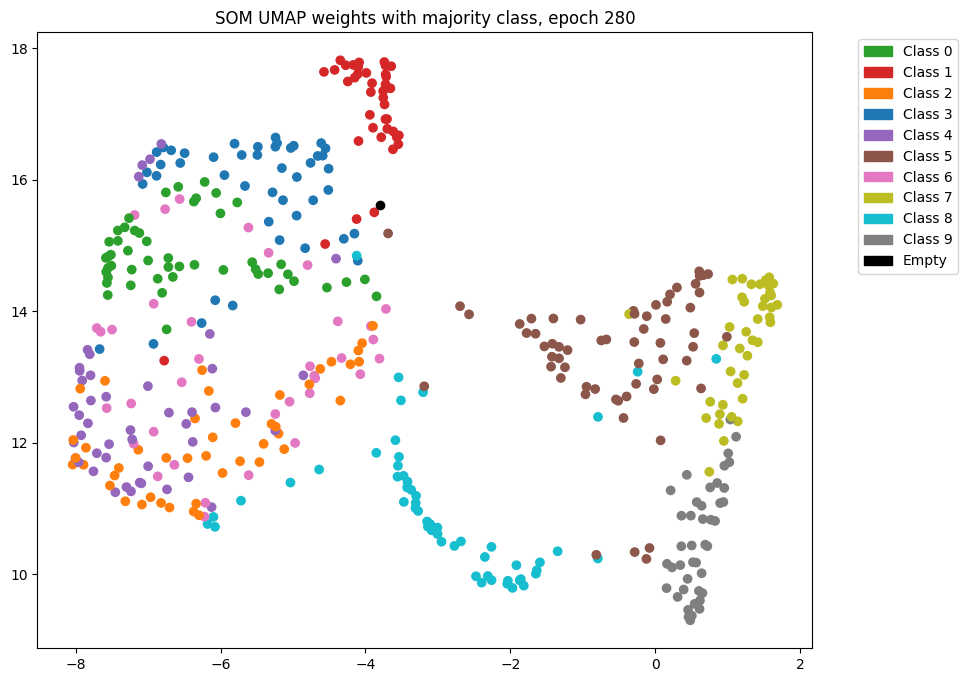

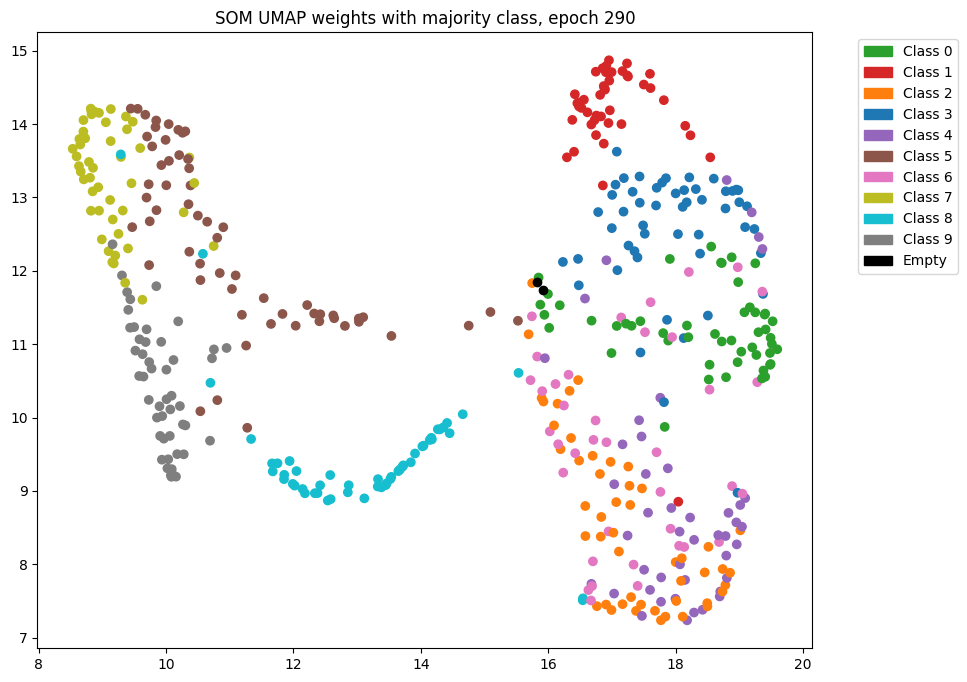

In [12]:
plot_umap_som_weights(snapshot_som_weights, unique_labels)

## Phase 3: ViT-GSOM Fine-Tuning

In [13]:
torch.save(autoencoder, "D:/Tom/ViT-GHSOM/model_fmnist.pth")

In [17]:
autoencoder = torch.load("D:/Tom/ViT-GHSOM/model.pth",weights_only=False)

In [18]:
autoencoder.get_som_shape()

(23, 22)

In [20]:
autoencoder.som_weights.shape

torch.Size([506, 784])

In [15]:
final_rows, final_cols = autoencoder.get_som_shape()

autoencoder.som_weights.requires_grad = True
for param in autoencoder.encoder.parameters():
    param.requires_grad = False
for param in autoencoder.decoder.parameters():
    param.requires_grad = False

paramsSOM = autoencoder.get_som_weights()
optimizerSOM = optim.AdamW([paramsSOM], lr=config['lr'])
scheduler = CosineAnnealingLR(optimizerSOM, T_max=config['fine_tuning_epochs'], last_epoch=-1)

sigma_start = 2
sigma_end = 0.01
beta = (sigma_end / sigma_start) ** (1 / config['fine_tuning_epochs'])

grid_coords = get_grid_coords(autoencoder.current_row_num, autoencoder.current_col_num, device)
current_sigma = sigma_start

checkpoints = [i for i in range(0, config['fine_tuning_epochs'] + 1, 10)]
snapshot_som_weights_finetuning = {}
snapshot_som_weights_finetuning[0] = (
    autoencoder.get_som_weights().detach().cpu().numpy(),
    get_node_hits(autoencoder, loader, device)
)

history = {'som': [], 'purity': [], 'QE': [], 'TE': []}

print("Start training")
for epoch in range(config['fine_tuning_epochs']):
    
    running_som = 0.0
    
    sigma_t = decay_exponential(sigma_start, beta, epoch)
    last_sigma = sigma_t
    
    for images, _ in loader:
        images = images.to(device)
        
        reconstructed, latent, _ = autoencoder(images)
        som_weights = autoencoder.get_som_weights()
        
        l_som = criterionSOM(latent, som_weights, grid_coords, sigma_t)
        
        optimizerSOM.zero_grad()
        l_som.backward()
        optimizerSOM.step()
        
        running_som += l_som.item()
    
    # updating learning rule through CosineAnnealingLR
    scheduler.step()

    metrics = calculate_QE_TE_Purity(autoencoder, loader, device)
    
    avg_som = running_som / len(loader)

    history['som'].append(avg_som)
    history['purity'].append(metrics["Purity"])
    history['QE'].append(metrics["QE"])
    history['TE'].append(metrics["TE"])
    
    print(f"Epoch {epoch+1}/{config['fine_tuning_epochs']} | Sigma: {sigma_t:.3f} | SOM: {avg_som:.8f} | QE: {metrics["QE"]:.4f} | TE: {metrics["TE"]:.4f} | Purity: {metrics["Purity"]:.5f}")

    if epoch+1 in checkpoints:        
        weights_np = autoencoder.get_som_weights().detach().cpu().numpy()
        labels_np = get_node_hits(autoencoder, loader, device)
        snapshot_som_weights_finetuning[epoch] = (weights_np, labels_np)

Start training
Epoch 1/100 | Sigma: 2.000 | SOM: 0.42955908 | QE: 0.0165 | TE: 0.0079 | Purity: 0.71627
Epoch 2/100 | Sigma: 1.897 | SOM: 0.37747578 | QE: 0.0163 | TE: 0.0083 | Purity: 0.71818
Epoch 3/100 | Sigma: 1.799 | SOM: 0.33790498 | QE: 0.0161 | TE: 0.0106 | Purity: 0.72273
Epoch 4/100 | Sigma: 1.706 | SOM: 0.30230696 | QE: 0.0159 | TE: 0.0120 | Purity: 0.72415
Epoch 5/100 | Sigma: 1.618 | SOM: 0.27103432 | QE: 0.0157 | TE: 0.0130 | Purity: 0.72882
Epoch 6/100 | Sigma: 1.535 | SOM: 0.24300980 | QE: 0.0155 | TE: 0.0142 | Purity: 0.73028
Epoch 7/100 | Sigma: 1.455 | SOM: 0.21761553 | QE: 0.0153 | TE: 0.0170 | Purity: 0.73527
Epoch 8/100 | Sigma: 1.380 | SOM: 0.19491605 | QE: 0.0151 | TE: 0.0176 | Purity: 0.73618
Epoch 9/100 | Sigma: 1.309 | SOM: 0.17461640 | QE: 0.0150 | TE: 0.0191 | Purity: 0.74088
Epoch 10/100 | Sigma: 1.241 | SOM: 0.15618010 | QE: 0.0148 | TE: 0.0203 | Purity: 0.74445
Epoch 11/100 | Sigma: 1.177 | SOM: 0.13972893 | QE: 0.0147 | TE: 0.0228 | Purity: 0.74792
Epoc

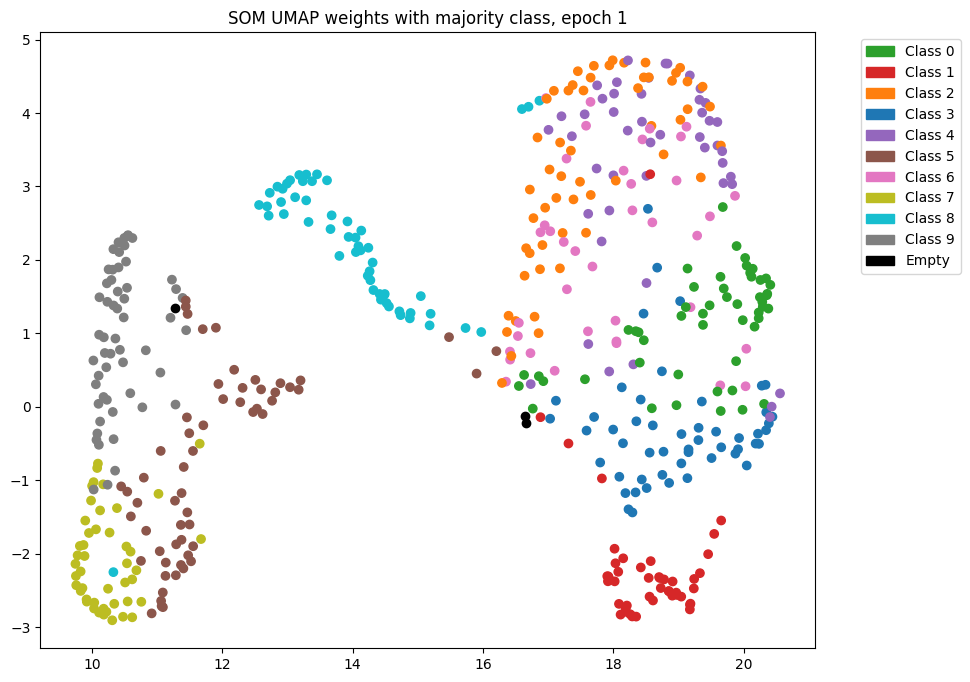

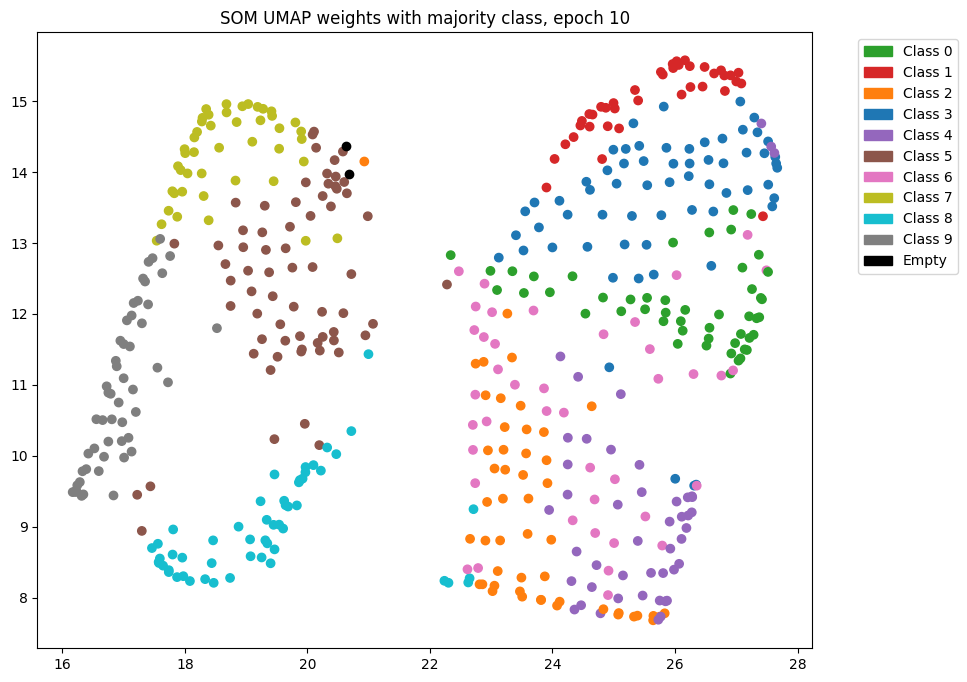

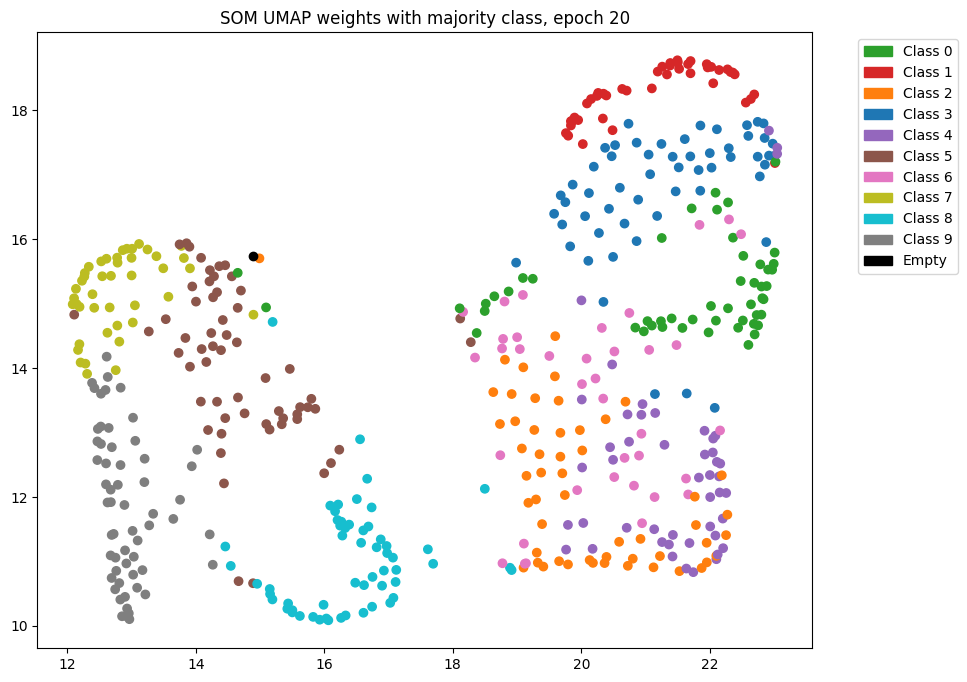

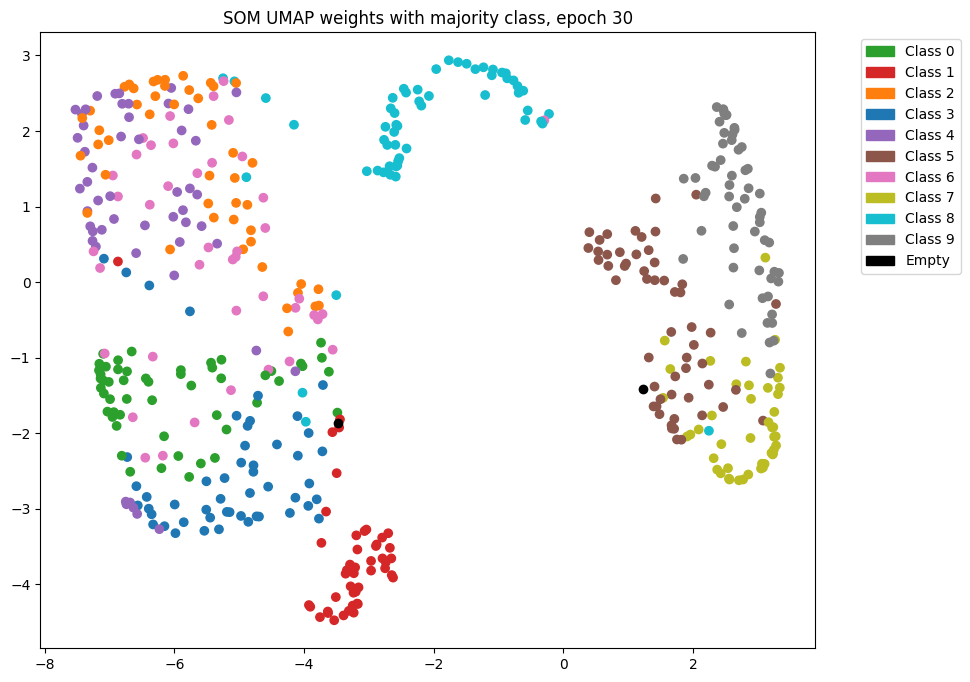

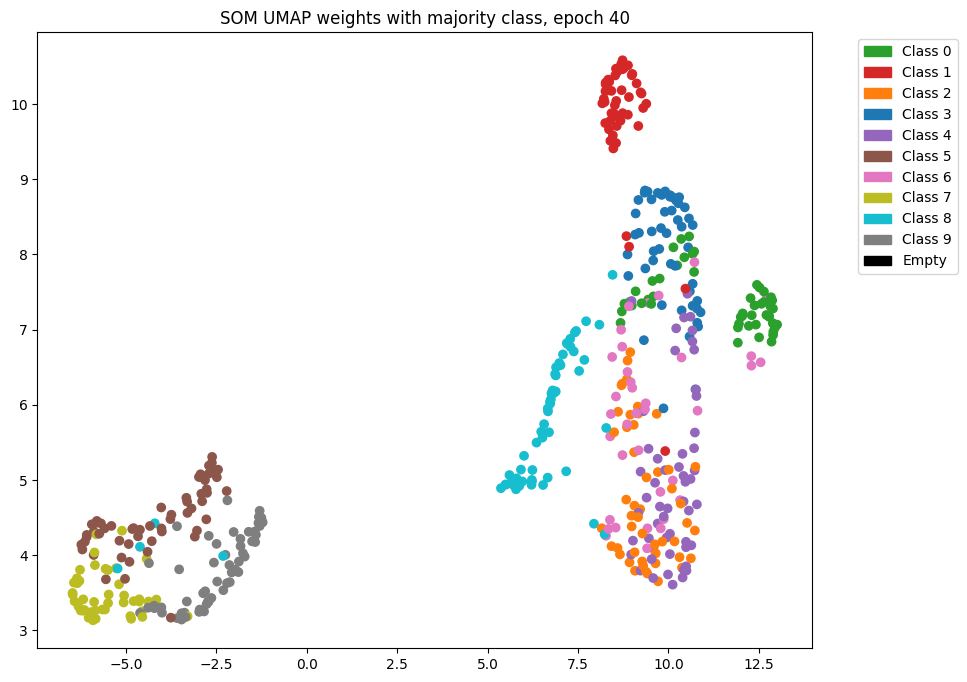

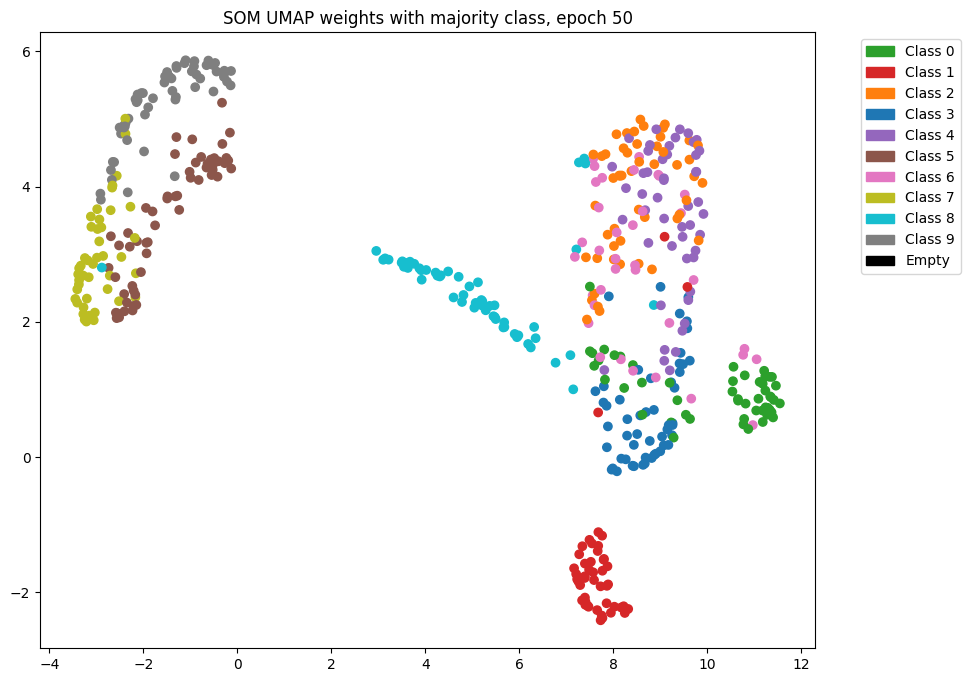

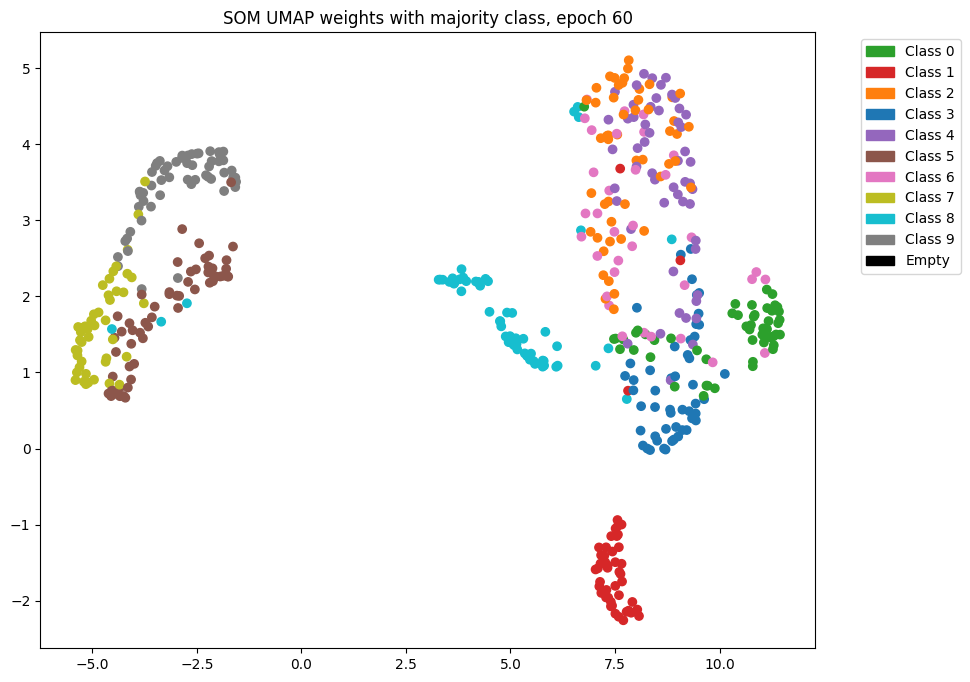

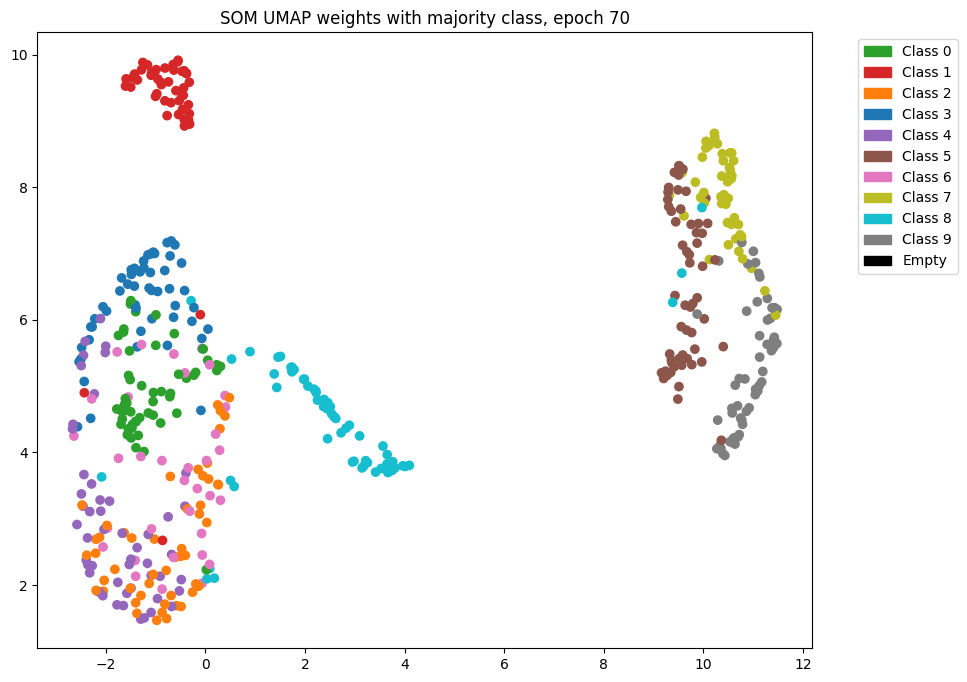

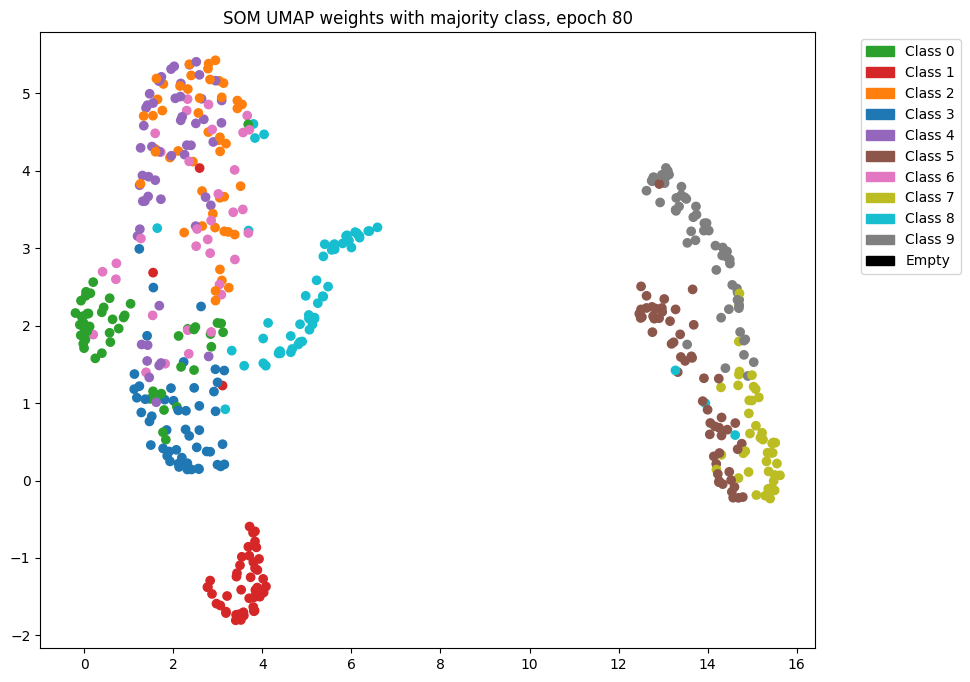

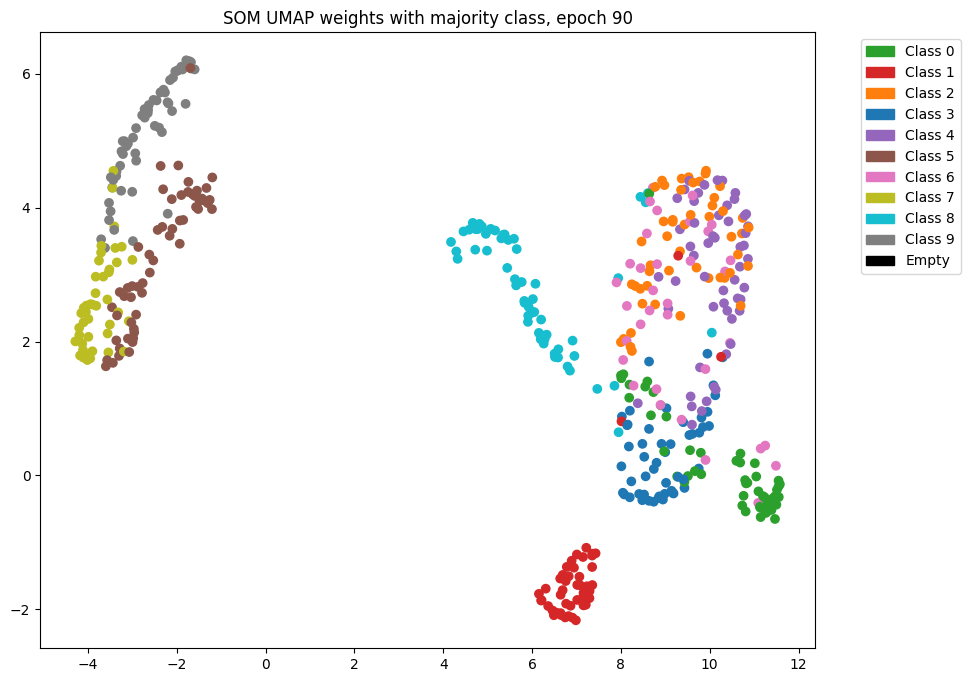

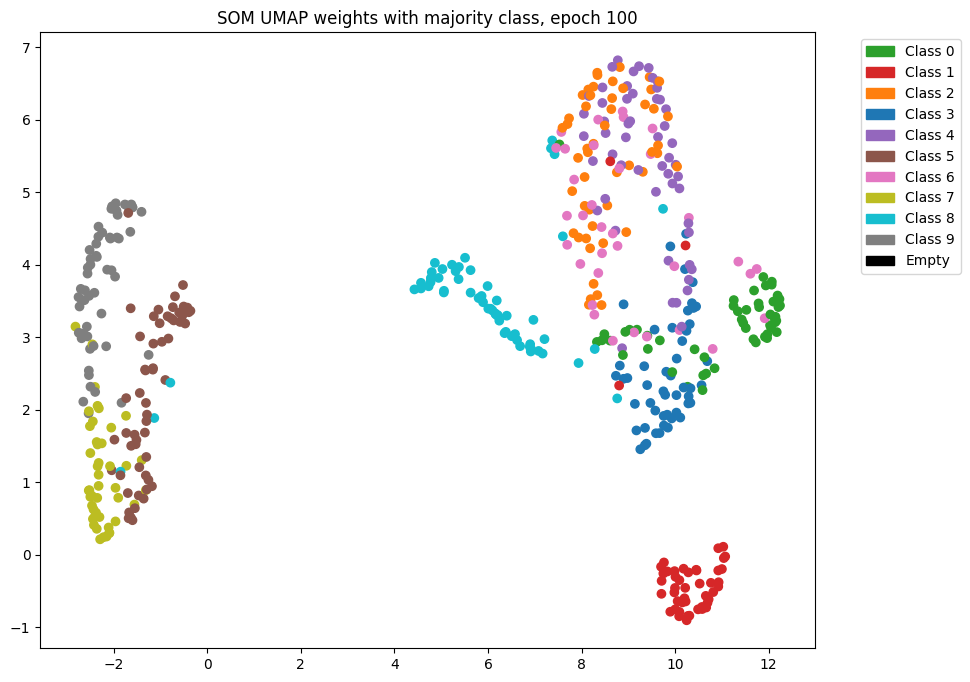

In [24]:
plot_umap_som_weights(snapshot_som_weights_finetuning, unique_labels)

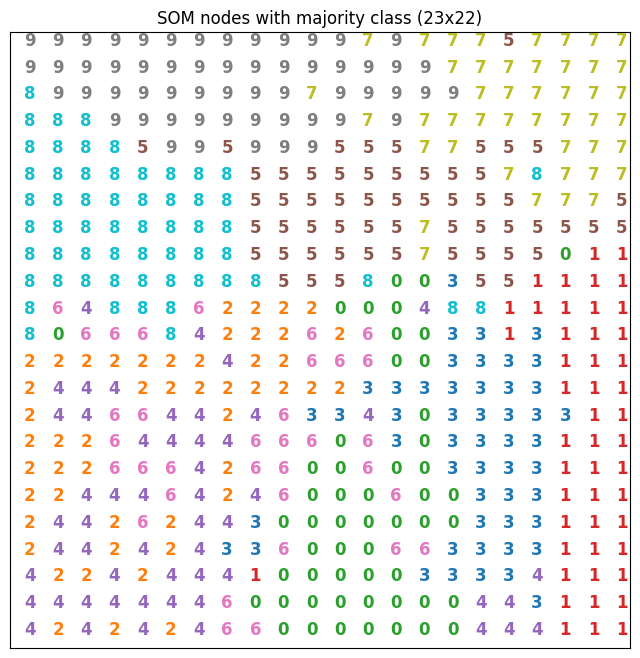

In [25]:
plot_som_mnist(snapshot_som_weights_finetuning, final_rows, final_cols)

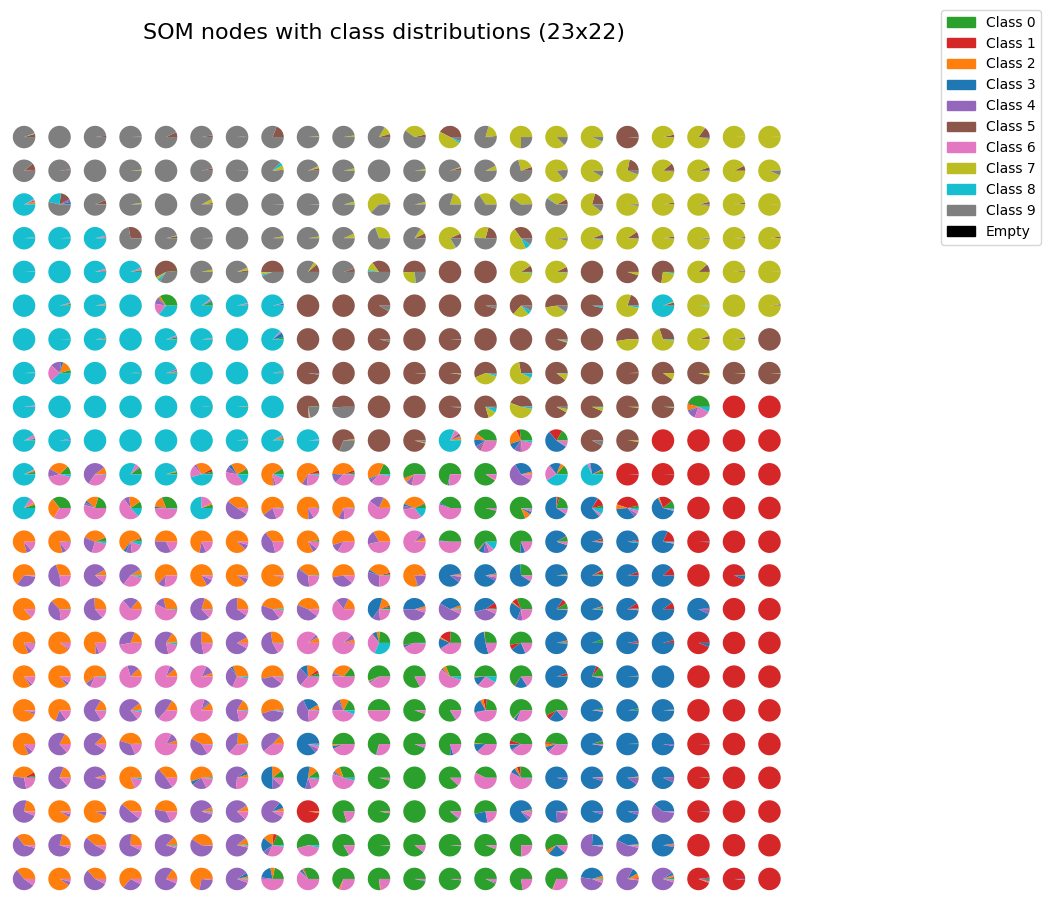

In [26]:
plot_som_pie_grid(snapshot_som_weights_finetuning, final_rows, final_cols, unique_labels)

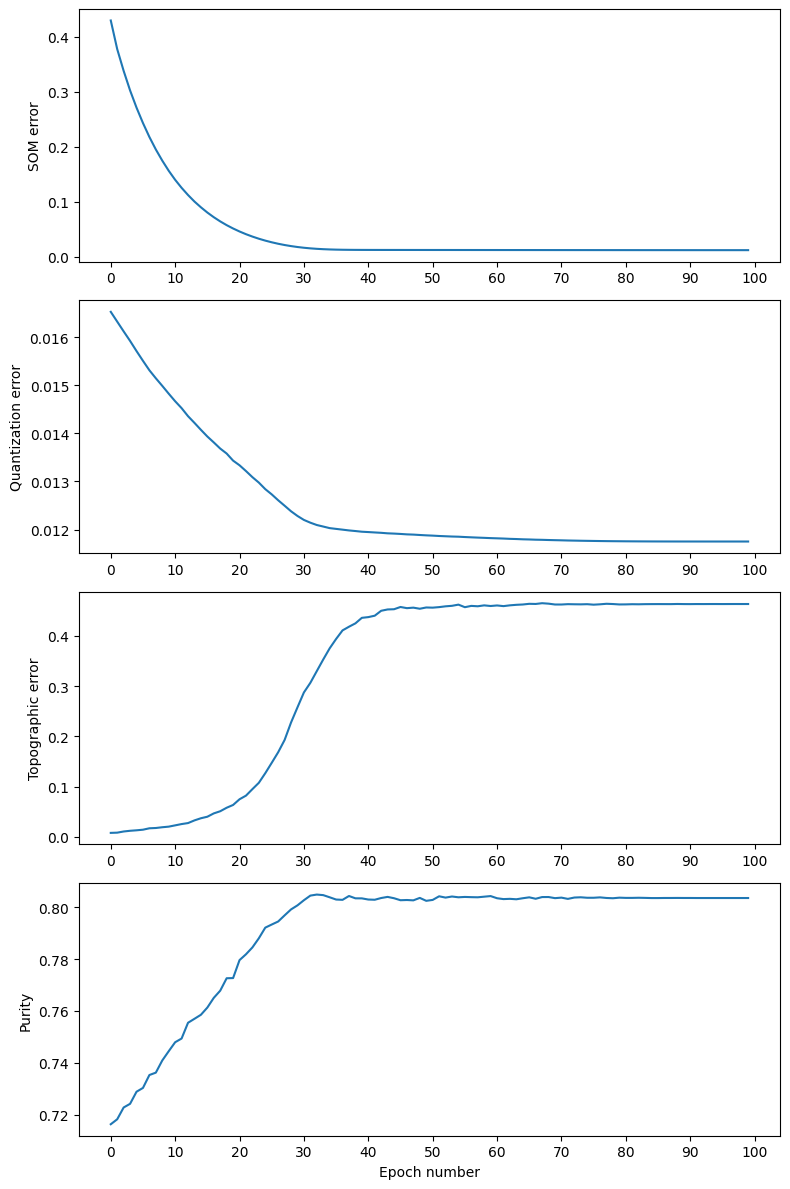

In [29]:
epochs_completed = len(history['QE'])
x = np.arange(epochs_completed)
xticks = np.arange(0, epochs_completed + 1, 10)

plt.figure(figsize=(8, 12))

plt.subplot(4,1,1)
plt.plot(x, history['som'])
plt.xticks(xticks)
plt.ylabel('SOM error')

plt.subplot(4,1,2)
plt.plot(x, history['QE'])
plt.xticks(xticks)
plt.ylabel('Quantization error')

plt.subplot(4,1,3)
plt.plot(x, history['TE'])
plt.xticks(xticks)
plt.ylabel('Topographic error')

plt.subplot(4,1,4)
plt.plot(x, history['purity'])
plt.xticks(xticks)
plt.ylabel('Purity')

plt.xlabel('Epoch number')
plt.tight_layout()
plt.show()

# Test 0,78 stop growth

In [3]:
config = {
    'img_size': 28,
    'patch_size': 4,
    'num_of_channels': 1,
    'embed_dim': 16,
    'enc_depth': 4,
    'dec_depth': 2,
    'num_heads': 2,
    'mlp_dim': 64,
    'epochs_pretrain': 20,
    'epochs_som': 500,
    'fine_tuning_epochs': 100,
    'lr': 0.0005,
    'grow_after_epochs': 10,
    'som_rows': 8,
    'som_cols': 8,
    'stop_growth_purity': 0.78
}

In [4]:
autoencoder = AutoEncoder(img_size=config['img_size'], 
                          patch_size=config['patch_size'], 
                          num_of_channels=config['num_of_channels'], 
                          embed_dim=config['embed_dim'], 
                          enc_depth=config['enc_depth'],                                      
                          dec_depth=config['dec_depth'], 
                          num_heads=config['num_heads'], 
                          mlp_dim=config['mlp_dim'],
                          som_rows=config['som_rows'],
                          som_cols=config['som_cols'])    

In [5]:
criterionViT = ViTLossReconstruction()
criterionSOM = SomLoss()

loader = torch.utils.data.DataLoader(dataset=dataset, batch_size=32, shuffle=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

autoencoder.to(device)
autoencoder.train()

AutoEncoder(
  (encoder): ViTEncoder(
    (patch_embed): PatchEmbedding(
      (proj): Conv2d(1, 16, kernel_size=(4, 4), stride=(4, 4))
    )
    (blocks): ModuleList(
      (0-3): 4 x Block(
        (attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=16, out_features=16, bias=True)
        )
        (ln1): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (dense_1): Linear(in_features=16, out_features=64, bias=True)
          (activation): GELU(approximate='none')
          (dense_2): Linear(in_features=64, out_features=16, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (ln2): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
      )
    )
    (ln1): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
  )
  (decoder): ViTDecoder(
    (blocks): ModuleList(
      (0-1): 2 x Block(
        (attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLine

In [6]:
autoencoder.som_weights.requires_grad = False
for param in autoencoder.encoder.parameters():
    param.requires_grad = True
for param in autoencoder.decoder.parameters():
    param.requires_grad = True
    
paramsViT = list(autoencoder.encoder.parameters()) + list(autoencoder.decoder.parameters())
optimizerViT = optim.AdamW(paramsViT, lr=config['lr'])
scheduler = CosineAnnealingLR(optimizerViT, T_max=config['epochs_pretrain'])

history = {'MSE': []}

for epoch in range(config['epochs_pretrain']):
    running_mse = 0.0
    
    for images, _ in loader:
        images = images.to(device)
        
        reconstructed, latent, _ = autoencoder(images)
        som_weights = autoencoder.get_som_weights()
        
        l_nn = criterionViT(images, reconstructed)
        
        optimizerViT.zero_grad()
        l_nn.backward()
        optimizerViT.step()
        running_mse += l_nn.item()
        
    scheduler.step()
    history['MSE'].append(running_mse/len(loader))
        
    print(f"Epoch {epoch+1}/{config['epochs_pretrain']}: MSE Loss {running_mse/len(loader):.8f}")

Epoch 1/20: MSE Loss 0.01468589
Epoch 2/20: MSE Loss 0.00246301
Epoch 3/20: MSE Loss 0.00152744
Epoch 4/20: MSE Loss 0.00112886
Epoch 5/20: MSE Loss 0.00086902
Epoch 6/20: MSE Loss 0.00075884
Epoch 7/20: MSE Loss 0.00070299
Epoch 8/20: MSE Loss 0.00067325
Epoch 9/20: MSE Loss 0.00064013
Epoch 10/20: MSE Loss 0.00049984
Epoch 11/20: MSE Loss 0.00044861
Epoch 12/20: MSE Loss 0.00042744
Epoch 13/20: MSE Loss 0.00041559
Epoch 14/20: MSE Loss 0.00040765
Epoch 15/20: MSE Loss 0.00040220
Epoch 16/20: MSE Loss 0.00039828
Epoch 17/20: MSE Loss 0.00039556
Epoch 18/20: MSE Loss 0.00039380
Epoch 19/20: MSE Loss 0.00039267
Epoch 20/20: MSE Loss 0.00039212


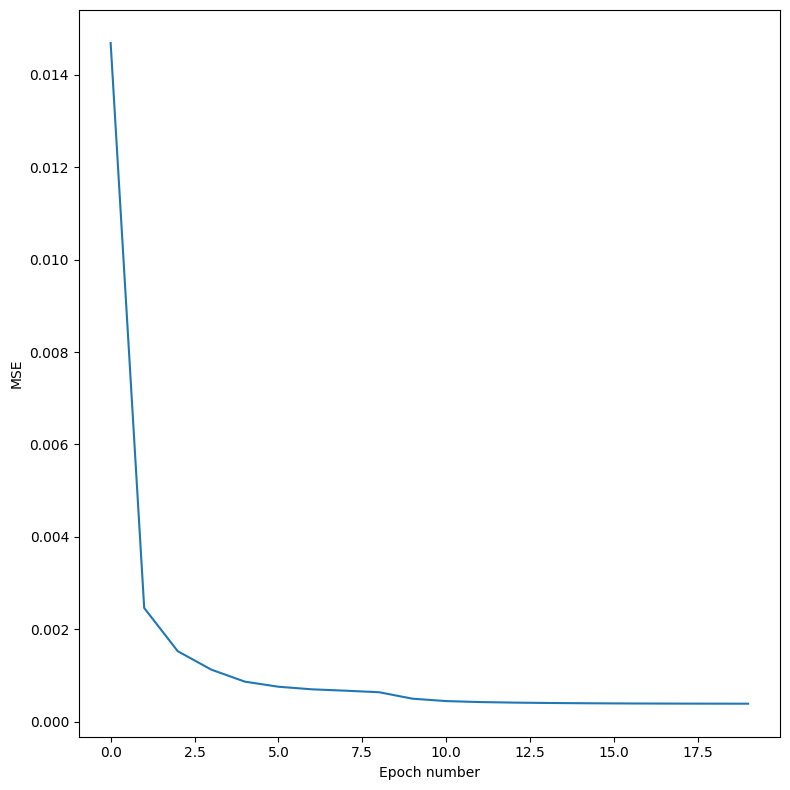

In [7]:
plt.figure(figsize=(8, 8))
plt.plot(np.arange(config['epochs_pretrain']), history['MSE'])
plt.ylabel('MSE')
plt.xlabel('Epoch number')
plt.tight_layout()
plt.show()

In [8]:
torch.save(autoencoder, "D:/Tom/ViT-GHSOM/model_fmnist_early_test.pth")

In [9]:
autoencoder.som_weights.requires_grad = True
for param in autoencoder.encoder.parameters():
    param.requires_grad = False
for param in autoencoder.decoder.parameters():
    param.requires_grad = False

paramsSOM = autoencoder.som_weights
optimizerSOM = optim.AdamW([paramsSOM], lr=config['lr'])
scheduler = CosineAnnealingLR(optimizerSOM, T_max=config['epochs_som'])

sigma_start = autoencoder.get_sigma()
sigma_end = 0.3
beta = (sigma_end / sigma_start) ** (1 / config['grow_after_epochs'])
epochs_since_reset = 0

grid_coords = get_grid_coords(config['som_rows'], config['som_cols'], device)
current_sigma = sigma_start

history = {'som': [], 'purity': [], 'QE': [], 'TE': []}


snapshot_som_weights = {}
snapshot_som_weights[0] = (
    autoencoder.get_som_weights().detach().cpu().numpy(),
    get_node_hits(autoencoder, loader, device)
)

unique_labels = set()

print("Start GSOM training")
for epoch in range(config['epochs_som']):
    
    running_som = 0.0
    
    sigma_t = decay_exponential(sigma_start, beta, epochs_since_reset)

    for images, labels in loader:
        images = images.to(device)
        unique_labels.update(labels.tolist())
        
        reconstructed, latent, _ = autoencoder(images)
        som_weights = autoencoder.get_som_weights()
        
        l_som = criterionSOM(latent, som_weights, grid_coords, sigma_t)
        
        optimizerSOM.zero_grad()
        l_som.backward()
        optimizerSOM.step()
        
        running_som += l_som.item()
    
    # updating learning rule through CosineAnnealingLR
    scheduler.step()

    metrics = calculate_QE_TE_Purity(autoencoder, loader, device)
    
    avg_som = running_som / len(loader)

    history['som'].append(avg_som)
    history['purity'].append(metrics["Purity"])
    history['QE'].append(metrics["QE"])
    history['TE'].append(metrics["TE"])
    
    print(f"Epoch {epoch+1}/{config['epochs_som']} | Sigma: {sigma_t:.3f} | SOM: {avg_som:.8f}) | QE: {metrics["QE"]:.4f} | TE: {metrics["TE"]:.4f} | Purity: {metrics["Purity"]:.5f}")
        
    if epoch > 0 and (epoch + 1) % config['grow_after_epochs'] == 0:     
        weights_np = autoencoder.get_som_weights().detach().cpu().numpy()
        labels_np = get_node_hits(autoencoder, loader, device)
        snapshot_som_weights[epoch] = (weights_np, labels_np)

        if metrics["Purity"] > config['stop_growth_purity']:
            print(f"Purity is high enough: {metrics["Purity"]}, entering Phase 3 - Fine-tuning")
            break
        
        epochs_since_reset += 1
        autoencoder.start_growth(loader, device)
        paramsSOM = autoencoder.get_som_weights()
        optimizerSOM = optim.AdamW([paramsSOM], lr=config['lr'])

        for param_group in optimizerSOM.param_groups: param_group['initial_lr'] = config['lr']

        scheduler = CosineAnnealingLR(optimizerSOM, T_max=config['epochs_som'], last_epoch=epoch)
        grid_coords = get_grid_coords(autoencoder.current_row_num, autoencoder.current_col_num, device)

        sigma_start = autoencoder.get_sigma()
        sigma_start = max(sigma_start, 2.0)
        beta = (sigma_end / sigma_start) ** (1 / max(1, config['grow_after_epochs']))
        epochs_since_reset = 0

    else:
        epochs_since_reset += 1   

Start GSOM training
Epoch 1/500 | Sigma: 4.000 | SOM: 20.90694902) | QE: 0.2555 | TE: 0.0886 | Purity: 0.10002
Epoch 2/500 | Sigma: 3.087 | SOM: 4.50875739) | QE: 0.0726 | TE: 0.0514 | Purity: 0.10060
Epoch 3/500 | Sigma: 2.383 | SOM: 1.05462497) | QE: 0.0468 | TE: 0.4898 | Purity: 0.13485
Epoch 4/500 | Sigma: 1.839 | SOM: 0.72510986) | QE: 0.0308 | TE: 0.0193 | Purity: 0.46605
Epoch 5/500 | Sigma: 1.419 | SOM: 0.34680486) | QE: 0.0245 | TE: 0.0011 | Purity: 0.59173
Epoch 6/500 | Sigma: 1.095 | SOM: 0.17265040) | QE: 0.0219 | TE: 0.0103 | Purity: 0.63707
Epoch 7/500 | Sigma: 0.845 | SOM: 0.09602306) | QE: 0.0204 | TE: 0.0149 | Purity: 0.66238
Epoch 8/500 | Sigma: 0.653 | SOM: 0.05573855) | QE: 0.0192 | TE: 0.0358 | Purity: 0.68305
Epoch 9/500 | Sigma: 0.504 | SOM: 0.03281262) | QE: 0.0181 | TE: 0.0780 | Purity: 0.69715
Epoch 10/500 | Sigma: 0.389 | SOM: 0.02136895) | QE: 0.0175 | TE: 0.1343 | Purity: 0.70135
Current grid size: (9, 8)
Epoch 11/500 | Sigma: 4.000 | SOM: 1.49795058) | QE:

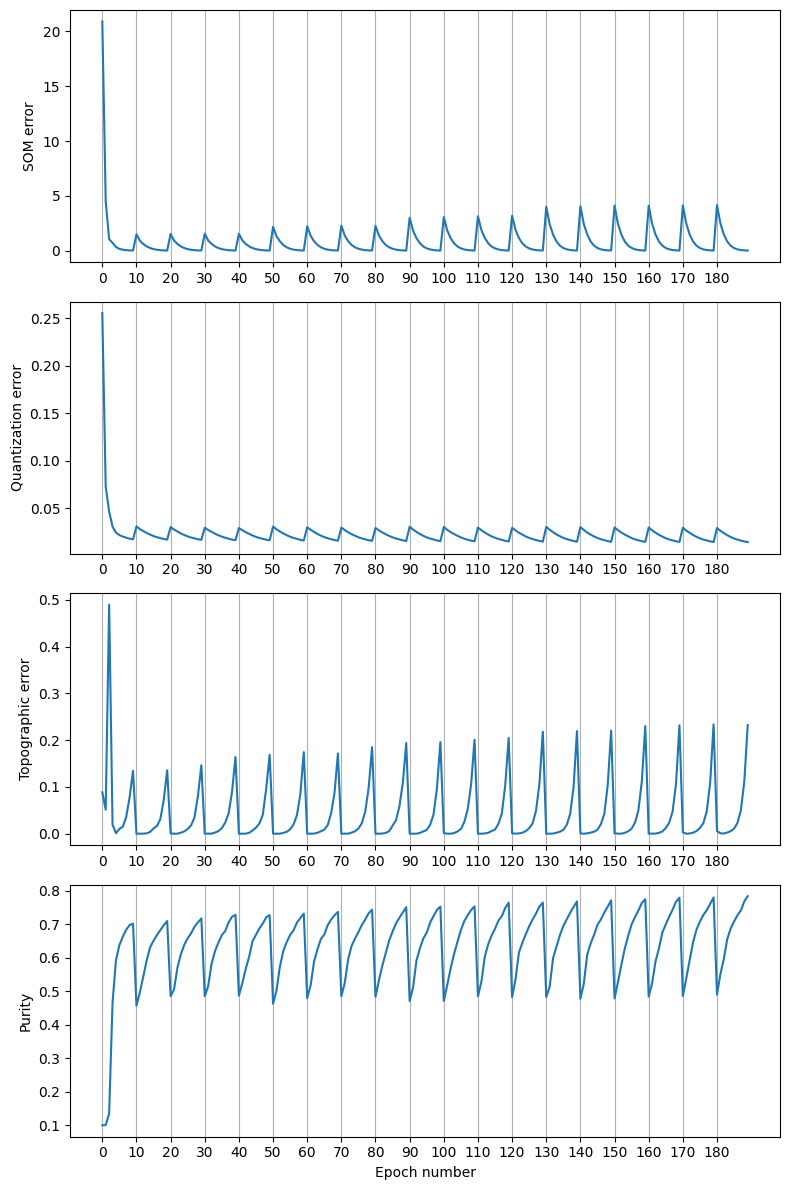

In [10]:
epochs_completed = len(history['QE'])
x = np.arange(epochs_completed)
xticks = np.arange(0, epochs_completed, 10)

plt.figure(figsize=(8, 12))

plt.subplot(4,1,1)
plt.plot(x, history['som'])
plt.xticks(xticks)
plt.grid(axis='x')
plt.ylabel('SOM error')

plt.subplot(4,1,2)
plt.plot(x, history['QE'])
plt.xticks(xticks)
plt.grid(axis='x')
plt.ylabel('Quantization error')

plt.subplot(4,1,3)
plt.plot(x, history['TE'])
plt.xticks(xticks)
plt.grid(axis='x')
plt.ylabel('Topographic error')

plt.subplot(4,1,4)
plt.plot(x, history['purity'])
plt.xticks(xticks)
plt.grid(axis='x')
plt.ylabel('Purity')

plt.xlabel('Epoch number')
plt.tight_layout()
plt.show()

In [11]:
torch.save(autoencoder, "D:/Tom/ViT-GHSOM/model_fmnist_test.pth")

In [13]:
final_rows, final_cols = autoencoder.get_som_shape()

autoencoder.som_weights.requires_grad = True
for param in autoencoder.encoder.parameters():
    param.requires_grad = False
for param in autoencoder.decoder.parameters():
    param.requires_grad = False

paramsSOM = autoencoder.get_som_weights()
optimizerSOM = optim.AdamW([paramsSOM], lr=config['lr'])
scheduler = CosineAnnealingLR(optimizerSOM, T_max=config['fine_tuning_epochs'], last_epoch=-1)

sigma_start = 2
sigma_end = 0.01
beta = (sigma_end / sigma_start) ** (1 / config['fine_tuning_epochs'])

grid_coords = get_grid_coords(autoencoder.current_row_num, autoencoder.current_col_num, device)
current_sigma = sigma_start

checkpoints = [i for i in range(0, config['fine_tuning_epochs'] + 1, 10)]
snapshot_som_weights_finetuning = {}
snapshot_som_weights_finetuning[0] = (
    autoencoder.get_som_weights().detach().cpu().numpy(),
    get_node_hits(autoencoder, loader, device)
)

history = {'som': [], 'purity': [], 'QE': [], 'TE': []}

print("Start training")
for epoch in range(config['fine_tuning_epochs']):
    
    running_som = 0.0
    
    sigma_t = decay_exponential(sigma_start, beta, epoch)
    last_sigma = sigma_t
    
    for images, _ in loader:
        images = images.to(device)
        
        reconstructed, latent, _ = autoencoder(images)
        som_weights = autoencoder.get_som_weights()
        
        l_som = criterionSOM(latent, som_weights, grid_coords, sigma_t)
        
        optimizerSOM.zero_grad()
        l_som.backward()
        optimizerSOM.step()
        
        running_som += l_som.item()
    
    # updating learning rule through CosineAnnealingLR
    scheduler.step()

    metrics = calculate_QE_TE_Purity(autoencoder, loader, device)
    
    avg_som = running_som / len(loader)

    history['som'].append(avg_som)
    history['purity'].append(metrics["Purity"])
    history['QE'].append(metrics["QE"])
    history['TE'].append(metrics["TE"])
    
    print(f"Epoch {epoch+1}/{config['fine_tuning_epochs']} | Sigma: {sigma_t:.3f} | SOM: {avg_som:.8f} | QE: {metrics["QE"]:.4f} | TE: {metrics["TE"]:.4f} | Purity: {metrics["Purity"]:.5f}")

    if epoch+1 in checkpoints:        
        weights_np = autoencoder.get_som_weights().detach().cpu().numpy()
        labels_np = get_node_hits(autoencoder, loader, device)
        snapshot_som_weights_finetuning[epoch] = (weights_np, labels_np)

Start training
Epoch 1/100 | Sigma: 2.000 | SOM: 0.48092954 | QE: 0.0199 | TE: 0.0060 | Purity: 0.68740
Epoch 2/100 | Sigma: 1.897 | SOM: 0.42344509 | QE: 0.0196 | TE: 0.0062 | Purity: 0.69007
Epoch 3/100 | Sigma: 1.799 | SOM: 0.38152985 | QE: 0.0193 | TE: 0.0064 | Purity: 0.69395
Epoch 4/100 | Sigma: 1.706 | SOM: 0.34306168 | QE: 0.0191 | TE: 0.0075 | Purity: 0.69437
Epoch 5/100 | Sigma: 1.618 | SOM: 0.30849254 | QE: 0.0189 | TE: 0.0087 | Purity: 0.69837
Epoch 6/100 | Sigma: 1.535 | SOM: 0.27701461 | QE: 0.0186 | TE: 0.0105 | Purity: 0.70273
Epoch 7/100 | Sigma: 1.455 | SOM: 0.24909105 | QE: 0.0184 | TE: 0.0110 | Purity: 0.70818
Epoch 8/100 | Sigma: 1.380 | SOM: 0.22367768 | QE: 0.0182 | TE: 0.0116 | Purity: 0.71057
Epoch 9/100 | Sigma: 1.309 | SOM: 0.20082365 | QE: 0.0179 | TE: 0.0143 | Purity: 0.71390
Epoch 10/100 | Sigma: 1.241 | SOM: 0.18024115 | QE: 0.0177 | TE: 0.0163 | Purity: 0.71790
Epoch 11/100 | Sigma: 1.177 | SOM: 0.16162163 | QE: 0.0175 | TE: 0.0195 | Purity: 0.72113
Epoc

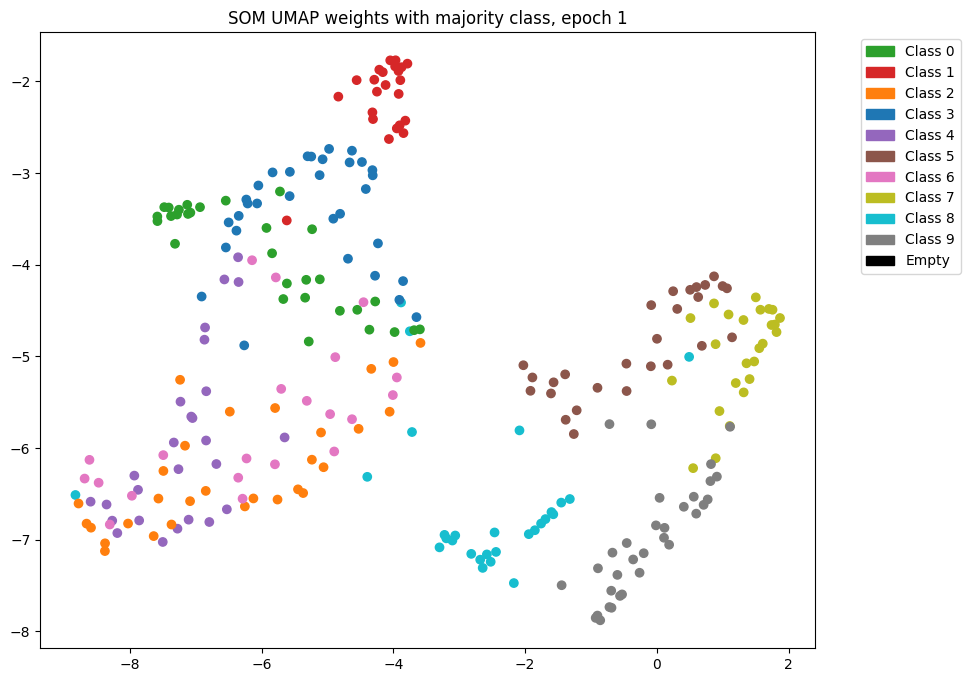

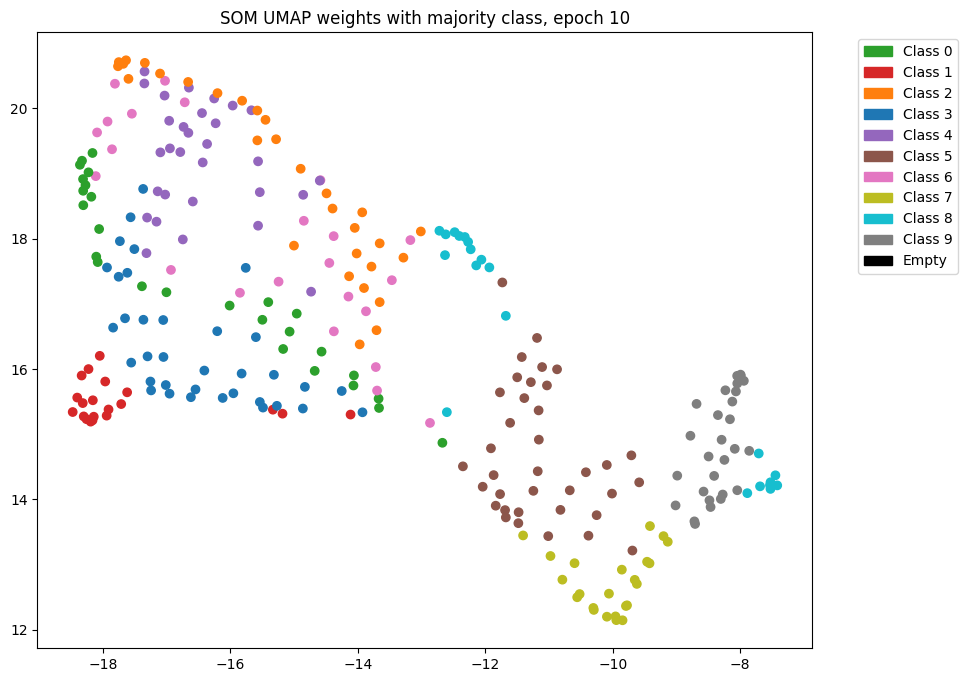

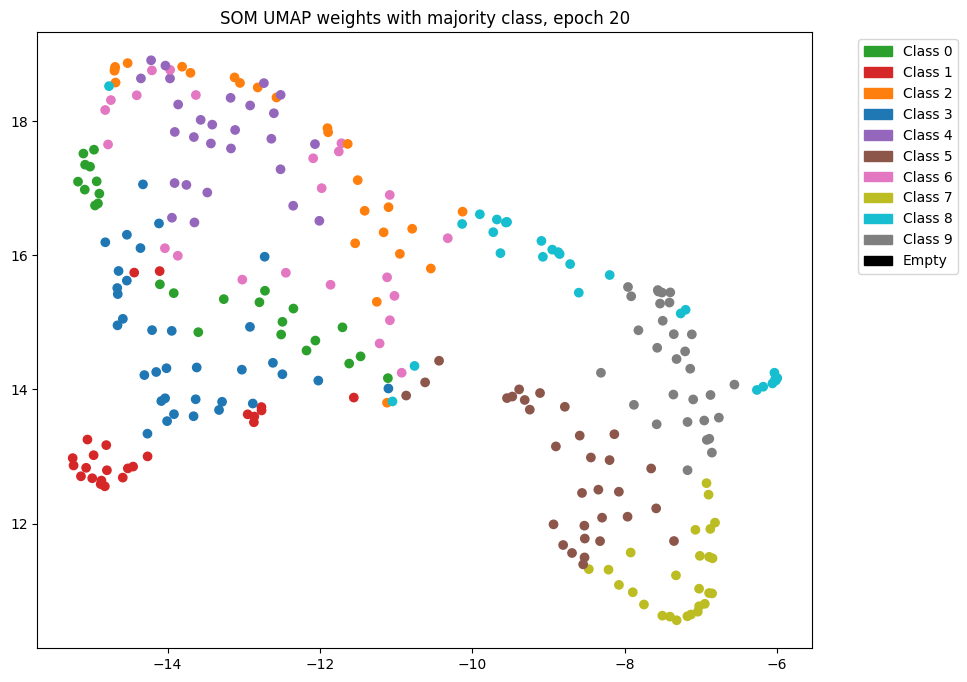

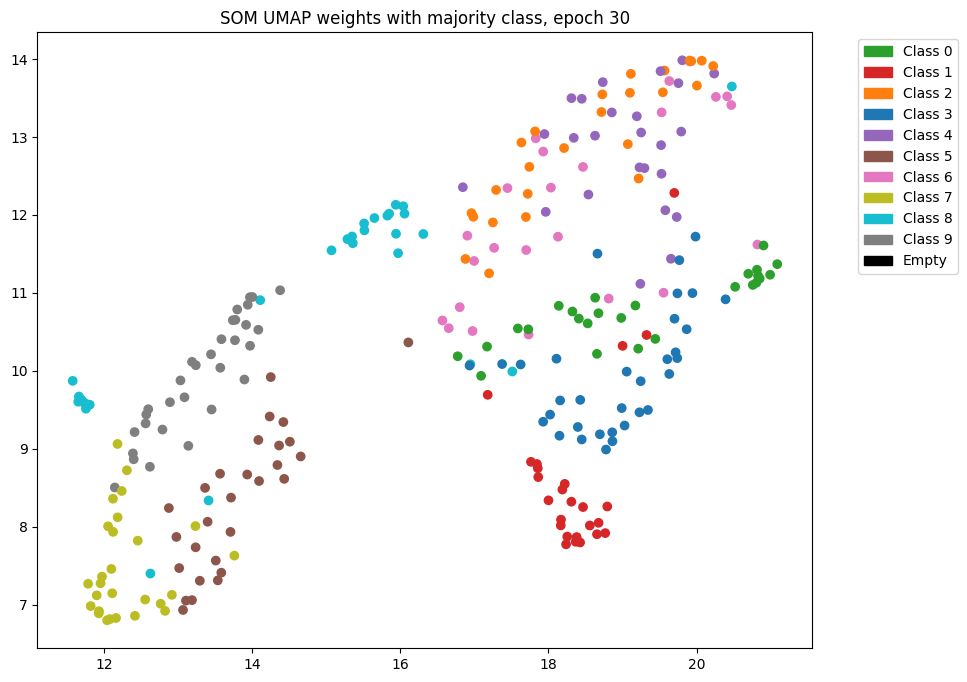

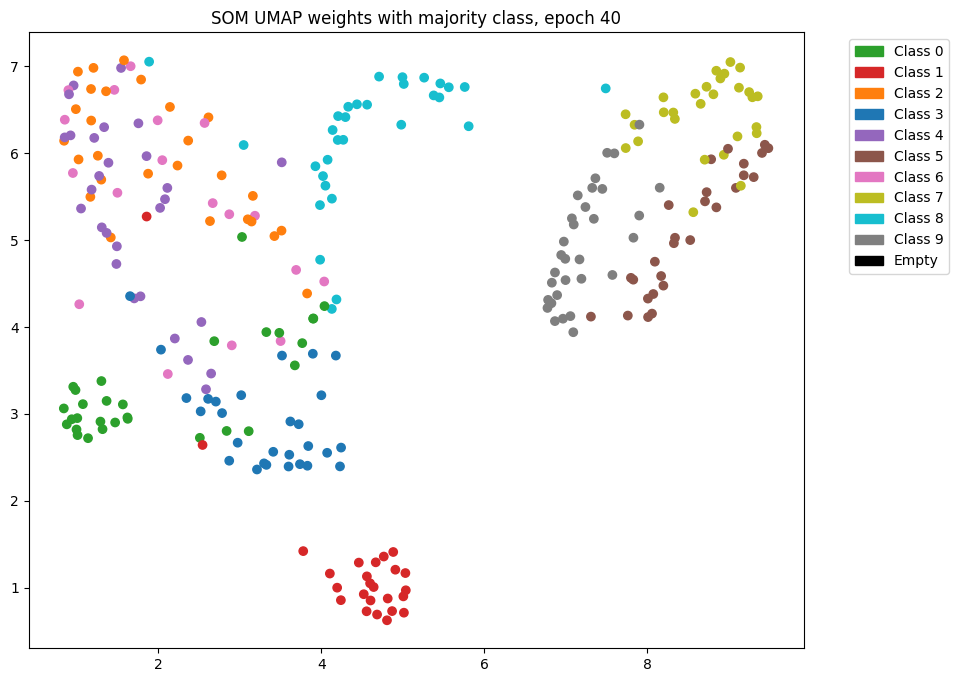

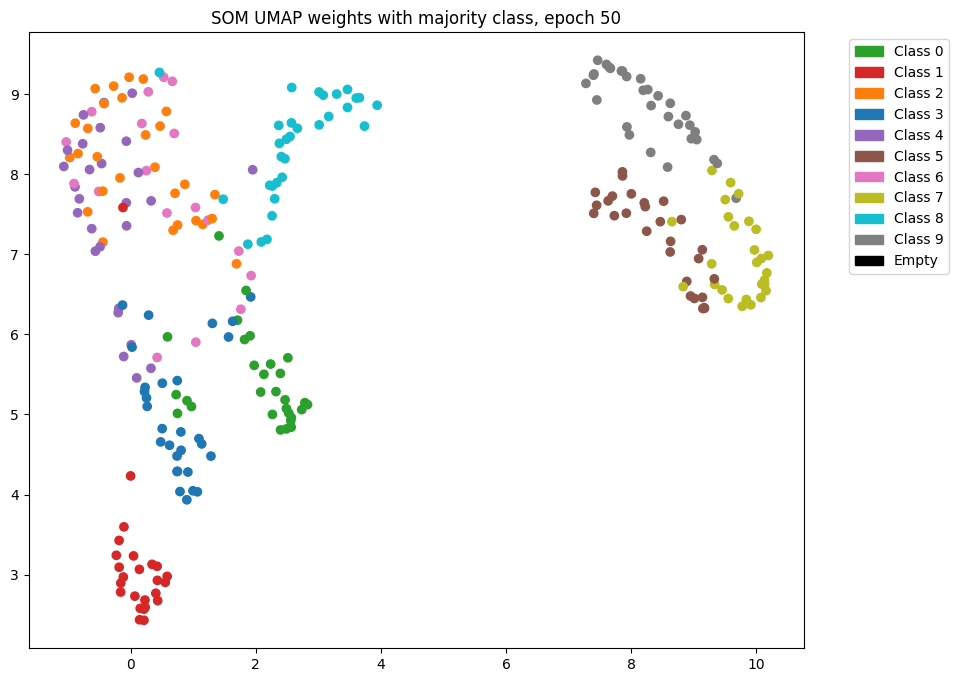

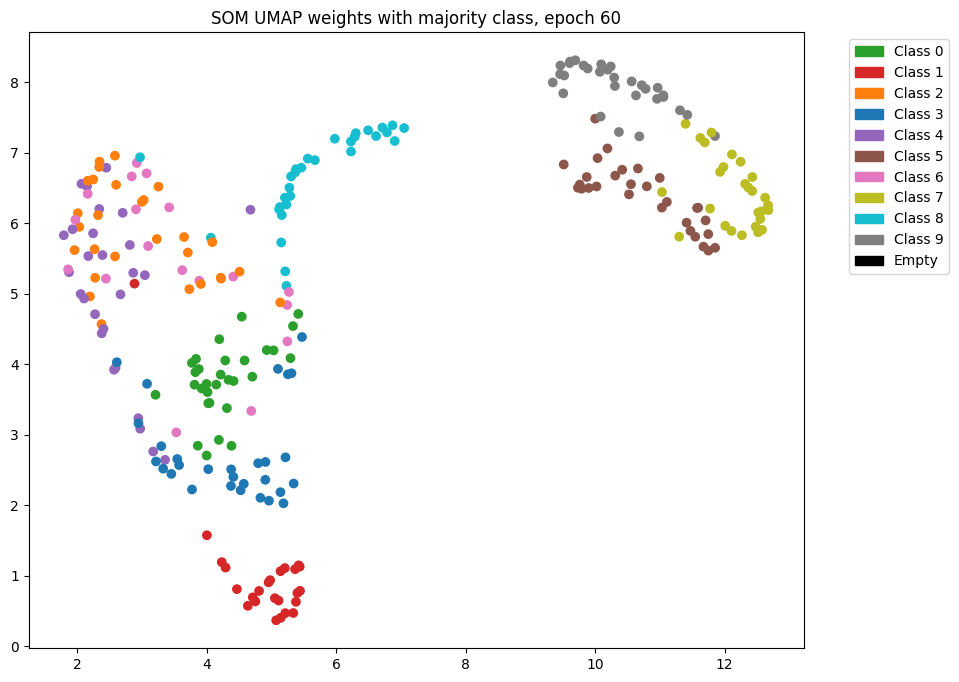

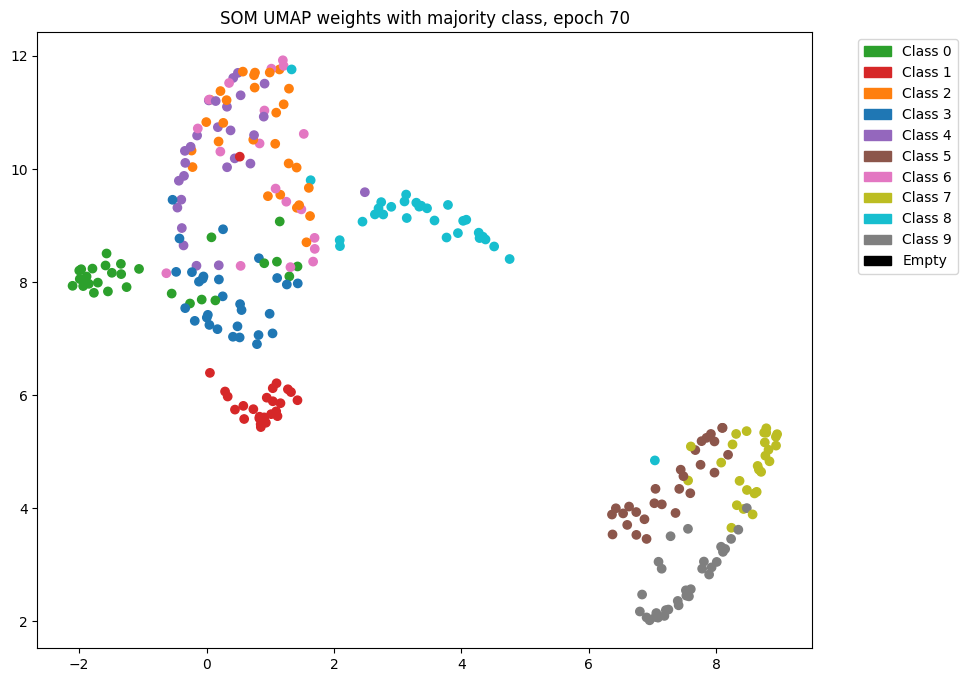

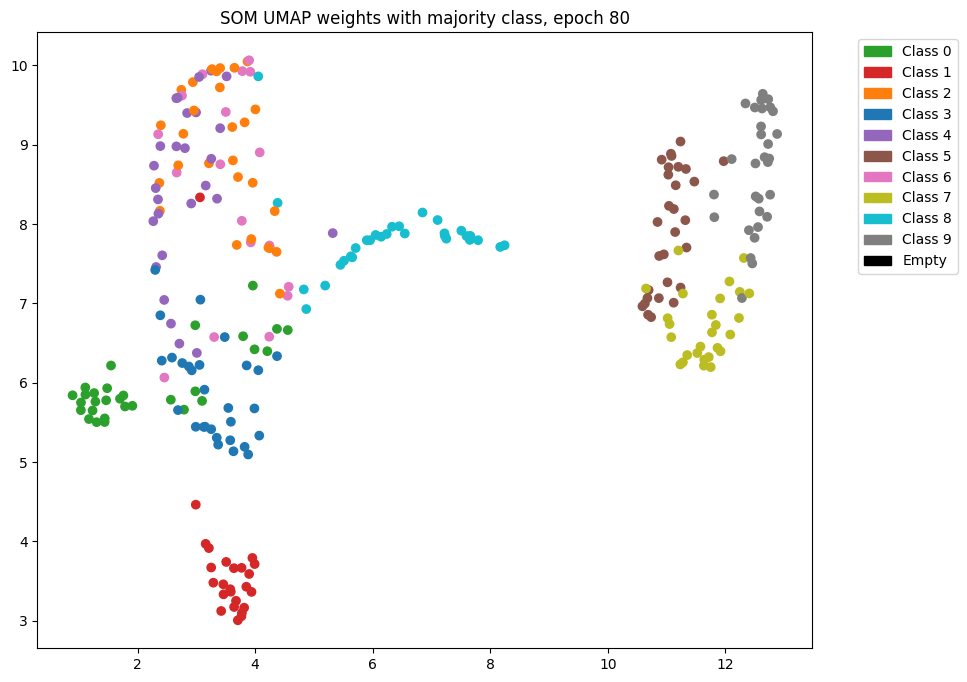

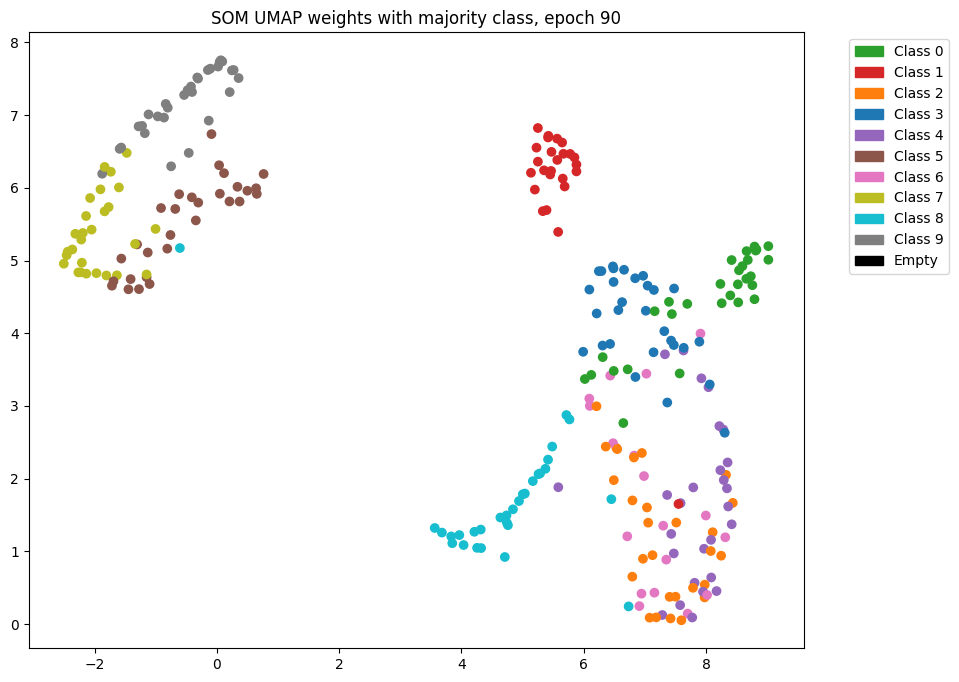

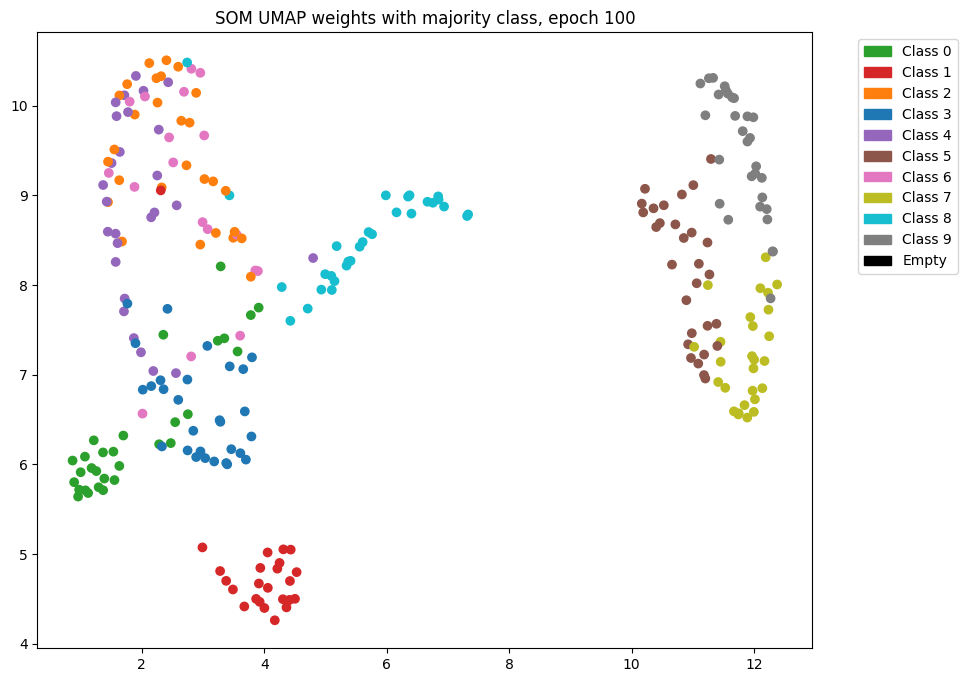

In [14]:
plot_umap_som_weights(snapshot_som_weights_finetuning, unique_labels)

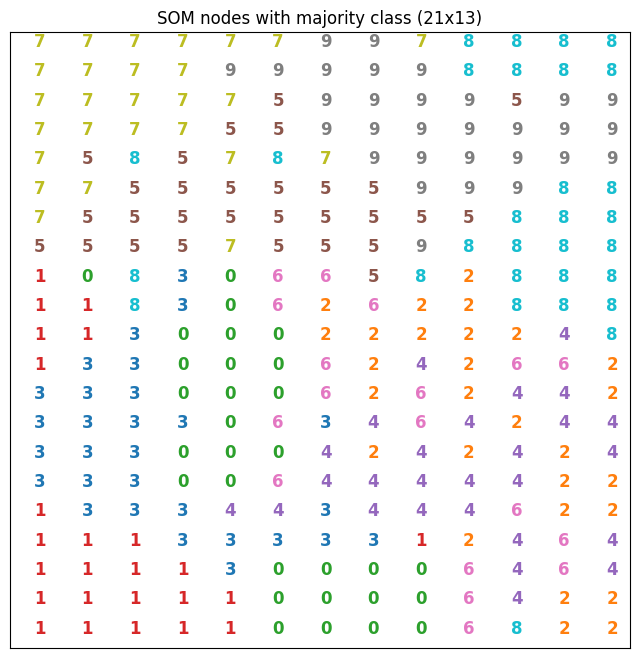

In [15]:
plot_som_mnist(snapshot_som_weights_finetuning, final_rows, final_cols)

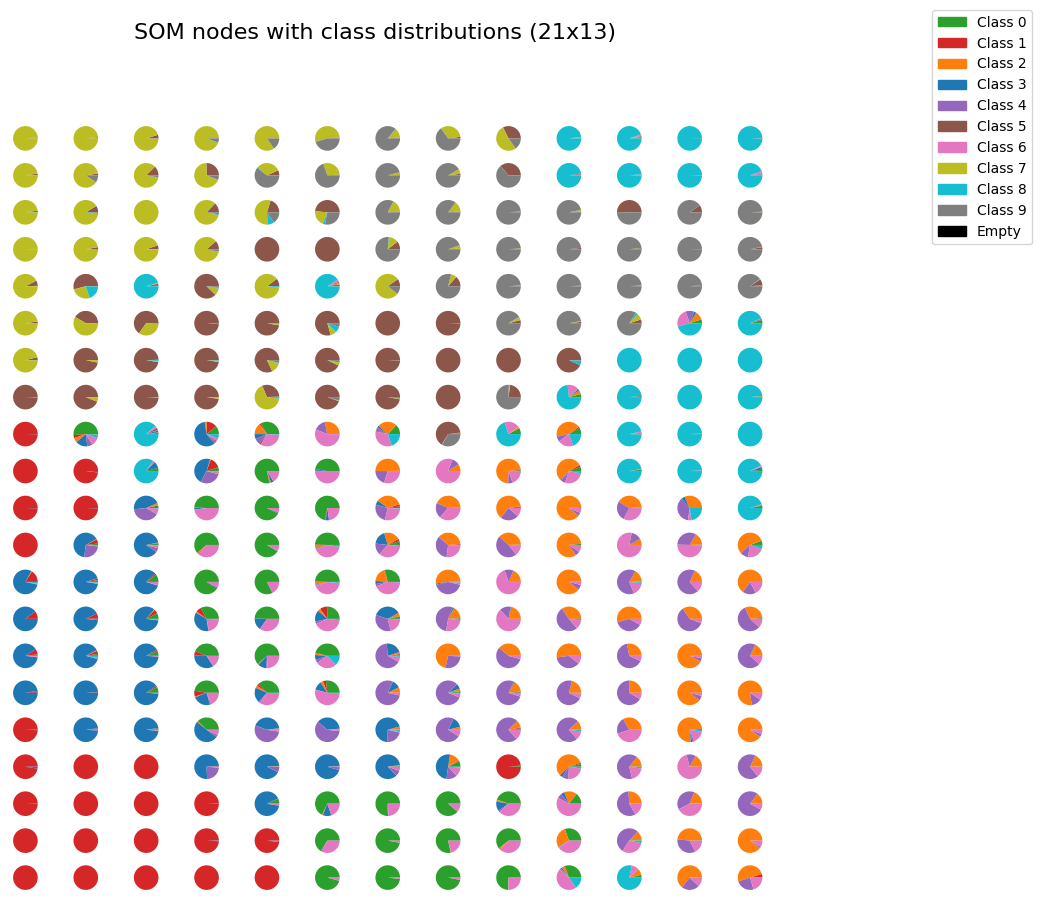

In [16]:
plot_som_pie_grid(snapshot_som_weights_finetuning, final_rows, final_cols, unique_labels)

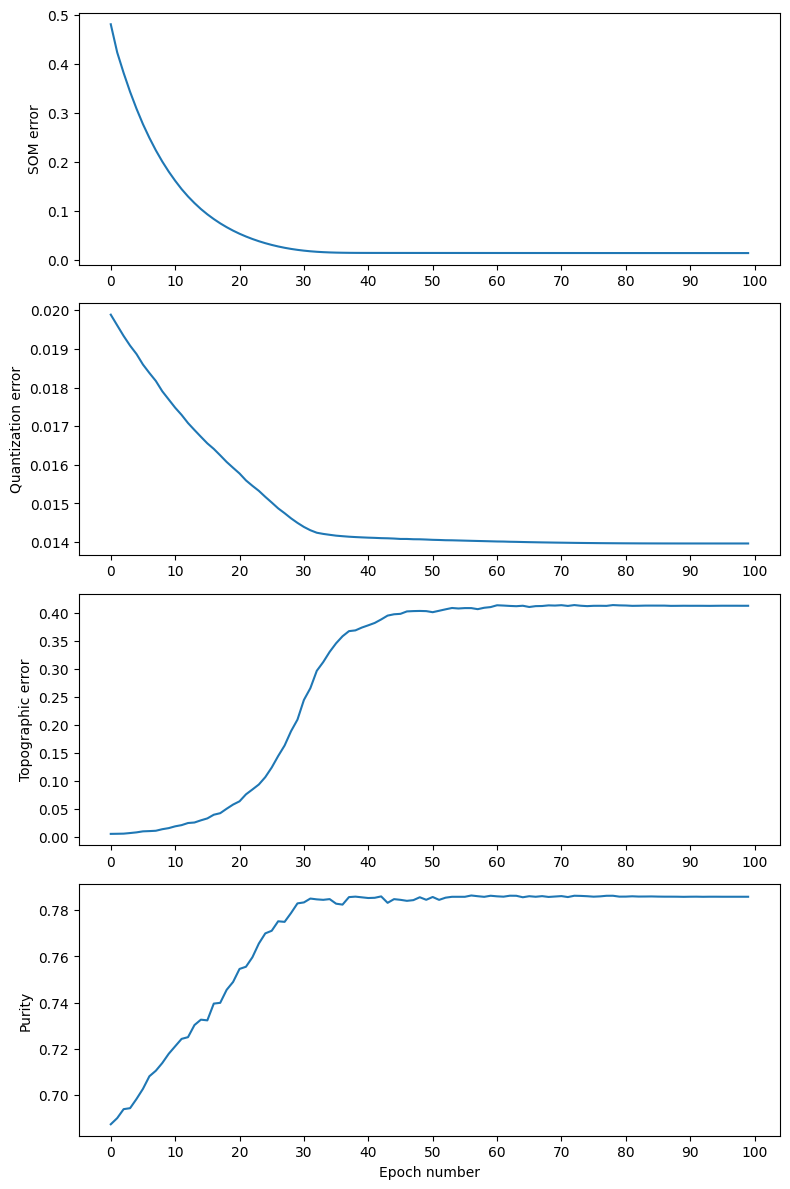

In [17]:
epochs_completed = len(history['QE'])
x = np.arange(epochs_completed)
xticks = np.arange(0, epochs_completed + 1, 10)

plt.figure(figsize=(8, 12))

plt.subplot(4,1,1)
plt.plot(x, history['som'])
plt.xticks(xticks)
plt.ylabel('SOM error')

plt.subplot(4,1,2)
plt.plot(x, history['QE'])
plt.xticks(xticks)
plt.ylabel('Quantization error')

plt.subplot(4,1,3)
plt.plot(x, history['TE'])
plt.xticks(xticks)
plt.ylabel('Topographic error')

plt.subplot(4,1,4)
plt.plot(x, history['purity'])
plt.xticks(xticks)
plt.ylabel('Purity')

plt.xlabel('Epoch number')
plt.tight_layout()
plt.show()